# Batch GCD y ataque sobre CT Logs

### **Autor:** David Quinzaños Saiz

Este notebook reúne en un único flujo las tres partes experimentales usadas en el TFM:

1. Implementación propia de `Binary Tree Batch GCD` en C++/GMP.
2. Reproducción sintética del experimento de Pelofske usando el repositorio del artículo y la implementación C++ propia.
3. Ataque final sobre módulos RSA reales extraídos de Certificate Transparency Logs.

Los módulos reales se obtuvieron a partir de certificados X.509 de emisores presentes en los ZIPs útiles del repositorio público `geomys/ct-archive`. Para cada log seleccionado se descargaron los ZIPs correspondientes, se extrajeron las entradas del directorio `issuer/`, se aplicó OpenSSL para obtener las líneas `Modulus=` de las claves públicas RSA y se normalizaron los valores a hexadecimal. Después se eliminaron duplicados tanto dentro de cada log como en el conjunto global, generando el fichero final `Datos/modulos.txt`, que contiene un módulo RSA único por línea.

La versión está pensada como notebook final de trabajo: contiene el código necesario para preparar la implementación C++, clonar y adaptar el repositorio del artículo si no está disponible, generar datos sintéticos, ejecutar la comparativa, producir tablas y figuras, documentar la extracción de módulos reales y lanzar el análisis sobre el conjunto real consolidado.

## Configuración general

El notebook está preparado para ejecutarse desde cero, pero permite separar la ejecución costosa del benchmark de la visualización de resultados. Si `RUN_SYNTHETIC_BENCHMARK_FROM_SCRATCH = True`, recalcula la comparativa completa. Si está a `False` y `LOAD_EXISTING_BENCHMARK_RESULTS = True`, carga los CSV ya generados para recuperar tablas y gráficas sin repetir horas de ejecución.


In [97]:
import importlib.util
import os
import random
import re
import shutil
import subprocess
import sys
import time
from pathlib import Path

REQUIRED_PACKAGES = {
    "psutil": "psutil",
    "matplotlib": "matplotlib",
    "pandas": "pandas",
    "numpy": "numpy",
    "Crypto": "pycryptodome",
}

missing_packages = [pkg for import_name, pkg in REQUIRED_PACKAGES.items() if importlib.util.find_spec(import_name) is None]
if missing_packages:
    print("Instalando dependencias Python que faltan:", ", ".join(missing_packages))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing_packages])

import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from Crypto.Util import number as crypto_number

# Compatibilidad con NumPy >= 2.0: el repositorio original usa np.product.
if not hasattr(np, "product"):
    np.product = np.prod

matplotlib.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 300,
})

# El notebook puede ejecutarse desde la raíz del repositorio o desde notebooks/.
CURRENT_DIR = Path.cwd()
PROJECT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

CODIGO_DIR = PROJECT_DIR / "codigo"
DATOS_DIR = PROJECT_DIR / "Datos"
CT_RAW_INPUT_DIR = DATOS_DIR / "ctlogs_raw"
CT_ARCHIVE_REPO = "https://github.com/geomys/ct-archive"
CT_ARCHIVE_URLS_FILE = DATOS_DIR / "ct_archive_urls_seleccionadas.txt"
RESULTADOS_DIR = PROJECT_DIR / "resultados"
RESULTS_BENCHMARK_DIR = RESULTADOS_DIR / "benchmark"
RESULTS_CTLOGS_DIR = RESULTADOS_DIR / "ctlogs"
BENCHMARK_DATA_DIR = RESULTS_BENCHMARK_DIR / "datos_sinteticos"
REPO_DIR = CODIGO_DIR / "binary_tree_Batch_GCD-main"
PRIMES_DIR = REPO_DIR / "primes"

for directory in [CODIGO_DIR, DATOS_DIR, CT_RAW_INPUT_DIR, RESULTS_BENCHMARK_DIR, RESULTS_CTLOGS_DIR, BENCHMARK_DATA_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

HEX_RE = re.compile(r"^[0-9A-Fa-f]+$")

RUN_SYNTHETIC_BENCHMARK_FROM_SCRATCH = False
LOAD_EXISTING_BENCHMARK_RESULTS = True
BENCHMARK_RESUME = True
RERUN_TIMEOUTS = True
RUN_REAL_BATCH_GCD = True
MAX_REPORTADOS = 20
TIMEOUT = None

print(f"Directorio proyecto:   {PROJECT_DIR}")
print(f"Directorio código:     {CODIGO_DIR}")
print(f"Repositorio Pelofske:  {REPO_DIR}")
print(f"Directorio datos:      {DATOS_DIR}")
print(f"Datos brutos CT Logs:  {CT_RAW_INPUT_DIR}")
print(f"Repositorio CT Archive:{CT_ARCHIVE_REPO}")
print(f"URLs CT seleccionadas: {CT_ARCHIVE_URLS_FILE}")
print(f"Resultados benchmark:  {RESULTS_BENCHMARK_DIR}")
print(f"Resultados CT Logs:    {RESULTS_CTLOGS_DIR}")


Directorio proyecto:   /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños
Directorio código:     /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/codigo
Repositorio Pelofske:  /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/codigo/binary_tree_Batch_GCD-main
Directorio datos:      /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/Datos
Datos brutos CT Logs:  /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/Datos/ctlogs_raw
Repositorio CT Archive:https://github.com/geomys/ct-archive
URLs CT seleccionadas: /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/Datos/ct_archive_urls_seleccionadas.txt
Resultados benchmark:  /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/resultados/benchmark
Resultados CT Logs:    /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/resultados/ctlogs


# Implementación C++/GMP de Binary Tree Batch GCD

La implementación usada en el ataque real se basa en el esquema `Binary Tree Batch GCD` propuesto por Pelofske, pero está reescrita en C++17 con GMP para reducir el coste práctico frente a las versiones Python.

El programa carga módulos RSA en hexadecimal, construye un árbol binario de productos, calcula GCDs no triviales durante la construcción, agrega los factores encontrados en una variable `B` y finalmente enumera los módulos vulnerables mediante `gcd(N_i, B)`.

El código C++ completo queda embebido en la celda siguiente. Al ejecutarla, el notebook escribe `codigo/batch_gcd_real.cpp` y muestra la implementación que se compilará en la sección posterior.


In [98]:
from IPython.display import Markdown, display

CPP_SOURCE = CODIGO_DIR / "batch_gcd_real.cpp"

CPP_CODE = '// =============================================================\n//  Binary Tree Batch GCD (Pelofske) — Datos reales (CT Logs)\n//  TFM: Vulnerabilidad de factores primos compartidos en RSA\n// =============================================================\n\n#include <iostream>\n#include <fstream>\n#include <vector>\n#include <string>\n#include <chrono>\n#include <iomanip>\n#include <cstdlib>\n#include <gmpxx.h>\n\n#ifdef _OPENMP\n#include <omp.h>\n#endif\n\nusing Clock = std::chrono::high_resolution_clock;\n\nint available_threads()\n{\n#ifdef _OPENMP\n    return omp_get_max_threads();\n#else\n    return 1;\n#endif\n}\n\n// ---------------------------------------------------------------\n//  Carga modulos RSA desde archivo (hex, uno por linea)\n// ---------------------------------------------------------------\nvoid load_moduli_from_file(const std::string& filename,\n                           std::vector<mpz_class>& moduli)\n{\n    std::ifstream file(filename);\n    if (!file.is_open()) {\n        std::cerr << "[ERROR] No se pudo abrir: " << filename << "\\n";\n        std::exit(1);\n    }\n\n    std::string line;\n    while (std::getline(file, line)) {\n        if (line.empty()) continue;\n        moduli.emplace_back(line, 16);\n    }\n    file.close();\n\n    std::cout << "[Setup] " << moduli.size()\n              << " modulos cargados desde " << filename << "\\n";\n    if (!moduli.empty()) {\n        std::cout << "  Primer modulo : " << mpz_sizeinbase(moduli.front().get_mpz_t(), 2)\n                  << " bits\\n";\n        std::cout << "  Ultimo modulo : " << mpz_sizeinbase(moduli.back().get_mpz_t(), 2)\n                  << " bits\\n\\n";\n    }\n}\n\n// ===============================================================\nint main(int argc, char* argv[])\n{\n    if (argc < 2) {\n        std::cerr << "Uso: " << argv[0] << " <archivo_modulos.txt> [max_reportados]\\n";\n        return 1;\n    }\n\n    std::string filename = argv[1];\n    int max_reported = 0;\n    if (argc >= 3) {\n        max_reported = std::max(0, std::atoi(argv[2]));\n    }\n\n    std::cout << "============================================\\n"\n              << " Binary Tree Batch GCD — Datos Reales\\n"\n              << "============================================\\n"\n              << "Archivo          : " << filename << "\\n"\n              << "Threads          : " << available_threads();\n#ifdef _OPENMP\n    std::cout << " (OpenMP)\\n";\n#else\n    std::cout << " (secuencial, sin OpenMP)\\n";\n#endif\n    std::cout\n              << "--------------------------------------------\\n\\n";\n\n    // --- Carga de modulos ---\n    std::vector<mpz_class> moduli;\n    {\n        auto t0 = Clock::now();\n        load_moduli_from_file(filename, moduli);\n        auto t1 = Clock::now();\n        std::cout << "  Tiempo de carga  : " << std::fixed << std::setprecision(2)\n                  << std::chrono::duration<double, std::milli>(t1 - t0).count()\n                  << " ms\\n\\n";\n    }\n\n    if (moduli.size() < 2) {\n        std::cerr << "[ERROR] Se necesitan al menos 2 modulos.\\n";\n        return 1;\n    }\n\n    // ==========================================================\n    //  FASE 1 — Arbol de productos + GCD en linea\n    //\n    //  Construye el arbol binario bottom-up.  En cada nodo:\n    //    1. GCD(hijo_izq, hijo_der) -> si > 1, se guarda\n    //    2. Producto hijo_izq * hijo_der -> sube al padre\n    //  Los hijos se liberan de inmediato para reducir Peak RAM.\n    // ==========================================================\n    std::vector<mpz_class> collected_gcds;\n    int tree_levels = 0;\n\n    auto t1_start = Clock::now();\n    {\n        std::vector<mpz_class> current(moduli.begin(), moduli.end());\n\n        while (current.size() > 1) {\n            size_t n      = current.size();\n            size_t pairs  = n / 2;\n            size_t next_n = (n + 1) / 2;\n            std::vector<mpz_class> next(next_n);\n\n            if (pairs >= 64) {\n#ifdef _OPENMP\n                int max_threads = available_threads();\n                std::vector<std::vector<mpz_class>> local_gcds(max_threads);\n\n                #pragma omp parallel for schedule(dynamic, 64)\n                for (size_t i = 0; i < pairs; i++) {\n                    mpz_class g;\n                    mpz_gcd(g.get_mpz_t(),\n                            current[2*i].get_mpz_t(),\n                            current[2*i + 1].get_mpz_t());\n                    if (g > 1) {\n                        local_gcds[omp_get_thread_num()].push_back(std::move(g));\n                    }\n                    mpz_mul(next[i].get_mpz_t(),\n                            current[2*i].get_mpz_t(),\n                            current[2*i + 1].get_mpz_t());\n                    current[2*i]     = mpz_class();\n                    current[2*i + 1] = mpz_class();\n                }\n\n                for (auto& lg : local_gcds)\n                    for (auto& g : lg)\n                        collected_gcds.push_back(std::move(g));\n#else\n                for (size_t i = 0; i < pairs; i++) {\n                    mpz_class g;\n                    mpz_gcd(g.get_mpz_t(),\n                            current[2*i].get_mpz_t(),\n                            current[2*i + 1].get_mpz_t());\n                    if (g > 1) {\n                        collected_gcds.push_back(std::move(g));\n                    }\n                    mpz_mul(next[i].get_mpz_t(),\n                            current[2*i].get_mpz_t(),\n                            current[2*i + 1].get_mpz_t());\n                    current[2*i]     = mpz_class();\n                    current[2*i + 1] = mpz_class();\n                }\n#endif\n            } else {\n                for (size_t i = 0; i < pairs; i++) {\n                    mpz_class g;\n                    mpz_gcd(g.get_mpz_t(),\n                            current[2*i].get_mpz_t(),\n                            current[2*i + 1].get_mpz_t());\n                    if (g > 1) {\n                        collected_gcds.push_back(std::move(g));\n                    }\n                    mpz_mul(next[i].get_mpz_t(),\n                            current[2*i].get_mpz_t(),\n                            current[2*i + 1].get_mpz_t());\n                    current[2*i]     = mpz_class();\n                    current[2*i + 1] = mpz_class();\n                }\n            }\n\n            if (n % 2 == 1) {\n                next[next_n - 1] = std::move(current[n - 1]);\n            }\n            current = std::move(next);\n            tree_levels++;\n        }\n    }\n    auto t1_end = Clock::now();\n\n    std::cout << "[Fase 1] Arbol de productos + GCD en linea\\n"\n              << "  Niveles construidos  : " << tree_levels << "\\n"\n              << "  GCDs no triviales    : " << collected_gcds.size() << "\\n"\n              << "  CPU Time             : " << std::fixed << std::setprecision(2)\n              << std::chrono::duration<double, std::milli>(t1_end - t1_start).count()\n              << " ms\\n\\n";\n\n    // ==========================================================\n    //  FASE 2 — Agregacion de factores compartidos en B\n    //\n    //  Multiplica todos los GCD no triviales en una unica\n    //  variable gigante B.\n    // ==========================================================\n    mpz_class B(1);\n\n    auto t2_start = Clock::now();\n    {\n        for (auto& g : collected_gcds) {\n            B *= g;\n        }\n        collected_gcds.clear();\n        collected_gcds.shrink_to_fit();\n    }\n    auto t2_end = Clock::now();\n\n    std::cout << "[Fase 2] Agregacion en variable B\\n"\n              << "  B bit-length         : "\n              << mpz_sizeinbase(B.get_mpz_t(), 2) << " bits\\n"\n              << "  CPU Time             : " << std::fixed << std::setprecision(2)\n              << std::chrono::duration<double, std::milli>(t2_end - t2_start).count()\n              << " ms\\n\\n";\n\n    // ==========================================================\n    //  FASE 3 — Enumeracion final (paralelizada con OpenMP)\n    //\n    //  Para cada modulo original N_i, calcula GCD(N_i, B).\n    //  Si el resultado != 1, la clave es vulnerable.\n    // ==========================================================\n    auto t3_start = Clock::now();\n    int found = 0;\n    int reported = 0;\n\n#ifdef _OPENMP\n    #pragma omp parallel for schedule(dynamic, 64) reduction(+:found)\n#endif\n    for (size_t i = 0; i < moduli.size(); i++) {\n        mpz_class g;\n        mpz_gcd(g.get_mpz_t(), moduli[i].get_mpz_t(), B.get_mpz_t());\n\n        if (g > 1) {\n#ifdef _OPENMP\n            #pragma omp critical\n#endif\n            {\n                if (reported < max_reported) {\n                    std::cout << "  [VULNERABLE] Key #" << std::setw(6) << i;\n                    if (g != moduli[i]) {\n                        mpz_class q = moduli[i] / g;\n                        std::cout << " | p = " << g.get_str().substr(0, 40) << "..."\n                                  << " | q = " << q.get_str().substr(0, 40) << "...";\n                    } else {\n                        std::cout << " | gcd(N_i, B) = N_i";\n                    }\n                    std::cout << "\\n";\n                    reported++;\n                }\n            }\n            found++;\n        }\n    }\n    auto t3_end = Clock::now();\n\n    std::cout << "\\n[Fase 3] Enumeracion final\\n"\n              << "  Claves vulnerables   : " << found << "\\n"\n              << "  CPU Time             : " << std::fixed << std::setprecision(2)\n              << std::chrono::duration<double, std::milli>(t3_end - t3_start).count()\n              << " ms\\n\\n";\n\n    // --- Resumen ---\n    double total_ms = std::chrono::duration<double, std::milli>(t3_end - t1_start).count();\n    std::cout << "============================================\\n"\n              << " Tiempo total algoritmo: " << std::fixed << std::setprecision(2)\n              << total_ms << " ms\\n"\n              << "============================================\\n";\n\n    return 0;\n}\n'

CPP_SOURCE.write_text(CPP_CODE, encoding="utf-8")
print(f"Código C++ escrito en: {CPP_SOURCE}")
print(f"Líneas de código C++: {len(CPP_CODE.splitlines())}")

display(Markdown("```cpp\n" + CPP_CODE + "\n```"))


Código C++ escrito en: /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/codigo/batch_gcd_real.cpp
Líneas de código C++: 275


```cpp
// =============================================================
//  Binary Tree Batch GCD (Pelofske) — Datos reales (CT Logs)
//  TFM: Vulnerabilidad de factores primos compartidos en RSA
// =============================================================

#include <iostream>
#include <fstream>
#include <vector>
#include <string>
#include <chrono>
#include <iomanip>
#include <cstdlib>
#include <gmpxx.h>

#ifdef _OPENMP
#include <omp.h>
#endif

using Clock = std::chrono::high_resolution_clock;

int available_threads()
{
#ifdef _OPENMP
    return omp_get_max_threads();
#else
    return 1;
#endif
}

// ---------------------------------------------------------------
//  Carga modulos RSA desde archivo (hex, uno por linea)
// ---------------------------------------------------------------
void load_moduli_from_file(const std::string& filename,
                           std::vector<mpz_class>& moduli)
{
    std::ifstream file(filename);
    if (!file.is_open()) {
        std::cerr << "[ERROR] No se pudo abrir: " << filename << "\n";
        std::exit(1);
    }

    std::string line;
    while (std::getline(file, line)) {
        if (line.empty()) continue;
        moduli.emplace_back(line, 16);
    }
    file.close();

    std::cout << "[Setup] " << moduli.size()
              << " modulos cargados desde " << filename << "\n";
    if (!moduli.empty()) {
        std::cout << "  Primer modulo : " << mpz_sizeinbase(moduli.front().get_mpz_t(), 2)
                  << " bits\n";
        std::cout << "  Ultimo modulo : " << mpz_sizeinbase(moduli.back().get_mpz_t(), 2)
                  << " bits\n\n";
    }
}

// ===============================================================
int main(int argc, char* argv[])
{
    if (argc < 2) {
        std::cerr << "Uso: " << argv[0] << " <archivo_modulos.txt> [max_reportados]\n";
        return 1;
    }

    std::string filename = argv[1];
    int max_reported = 0;
    if (argc >= 3) {
        max_reported = std::max(0, std::atoi(argv[2]));
    }

    std::cout << "============================================\n"
              << " Binary Tree Batch GCD — Datos Reales\n"
              << "============================================\n"
              << "Archivo          : " << filename << "\n"
              << "Threads          : " << available_threads();
#ifdef _OPENMP
    std::cout << " (OpenMP)\n";
#else
    std::cout << " (secuencial, sin OpenMP)\n";
#endif
    std::cout
              << "--------------------------------------------\n\n";

    // --- Carga de modulos ---
    std::vector<mpz_class> moduli;
    {
        auto t0 = Clock::now();
        load_moduli_from_file(filename, moduli);
        auto t1 = Clock::now();
        std::cout << "  Tiempo de carga  : " << std::fixed << std::setprecision(2)
                  << std::chrono::duration<double, std::milli>(t1 - t0).count()
                  << " ms\n\n";
    }

    if (moduli.size() < 2) {
        std::cerr << "[ERROR] Se necesitan al menos 2 modulos.\n";
        return 1;
    }

    // ==========================================================
    //  FASE 1 — Arbol de productos + GCD en linea
    //
    //  Construye el arbol binario bottom-up.  En cada nodo:
    //    1. GCD(hijo_izq, hijo_der) -> si > 1, se guarda
    //    2. Producto hijo_izq * hijo_der -> sube al padre
    //  Los hijos se liberan de inmediato para reducir Peak RAM.
    // ==========================================================
    std::vector<mpz_class> collected_gcds;
    int tree_levels = 0;

    auto t1_start = Clock::now();
    {
        std::vector<mpz_class> current(moduli.begin(), moduli.end());

        while (current.size() > 1) {
            size_t n      = current.size();
            size_t pairs  = n / 2;
            size_t next_n = (n + 1) / 2;
            std::vector<mpz_class> next(next_n);

            if (pairs >= 64) {
#ifdef _OPENMP
                int max_threads = available_threads();
                std::vector<std::vector<mpz_class>> local_gcds(max_threads);

                #pragma omp parallel for schedule(dynamic, 64)
                for (size_t i = 0; i < pairs; i++) {
                    mpz_class g;
                    mpz_gcd(g.get_mpz_t(),
                            current[2*i].get_mpz_t(),
                            current[2*i + 1].get_mpz_t());
                    if (g > 1) {
                        local_gcds[omp_get_thread_num()].push_back(std::move(g));
                    }
                    mpz_mul(next[i].get_mpz_t(),
                            current[2*i].get_mpz_t(),
                            current[2*i + 1].get_mpz_t());
                    current[2*i]     = mpz_class();
                    current[2*i + 1] = mpz_class();
                }

                for (auto& lg : local_gcds)
                    for (auto& g : lg)
                        collected_gcds.push_back(std::move(g));
#else
                for (size_t i = 0; i < pairs; i++) {
                    mpz_class g;
                    mpz_gcd(g.get_mpz_t(),
                            current[2*i].get_mpz_t(),
                            current[2*i + 1].get_mpz_t());
                    if (g > 1) {
                        collected_gcds.push_back(std::move(g));
                    }
                    mpz_mul(next[i].get_mpz_t(),
                            current[2*i].get_mpz_t(),
                            current[2*i + 1].get_mpz_t());
                    current[2*i]     = mpz_class();
                    current[2*i + 1] = mpz_class();
                }
#endif
            } else {
                for (size_t i = 0; i < pairs; i++) {
                    mpz_class g;
                    mpz_gcd(g.get_mpz_t(),
                            current[2*i].get_mpz_t(),
                            current[2*i + 1].get_mpz_t());
                    if (g > 1) {
                        collected_gcds.push_back(std::move(g));
                    }
                    mpz_mul(next[i].get_mpz_t(),
                            current[2*i].get_mpz_t(),
                            current[2*i + 1].get_mpz_t());
                    current[2*i]     = mpz_class();
                    current[2*i + 1] = mpz_class();
                }
            }

            if (n % 2 == 1) {
                next[next_n - 1] = std::move(current[n - 1]);
            }
            current = std::move(next);
            tree_levels++;
        }
    }
    auto t1_end = Clock::now();

    std::cout << "[Fase 1] Arbol de productos + GCD en linea\n"
              << "  Niveles construidos  : " << tree_levels << "\n"
              << "  GCDs no triviales    : " << collected_gcds.size() << "\n"
              << "  CPU Time             : " << std::fixed << std::setprecision(2)
              << std::chrono::duration<double, std::milli>(t1_end - t1_start).count()
              << " ms\n\n";

    // ==========================================================
    //  FASE 2 — Agregacion de factores compartidos en B
    //
    //  Multiplica todos los GCD no triviales en una unica
    //  variable gigante B.
    // ==========================================================
    mpz_class B(1);

    auto t2_start = Clock::now();
    {
        for (auto& g : collected_gcds) {
            B *= g;
        }
        collected_gcds.clear();
        collected_gcds.shrink_to_fit();
    }
    auto t2_end = Clock::now();

    std::cout << "[Fase 2] Agregacion en variable B\n"
              << "  B bit-length         : "
              << mpz_sizeinbase(B.get_mpz_t(), 2) << " bits\n"
              << "  CPU Time             : " << std::fixed << std::setprecision(2)
              << std::chrono::duration<double, std::milli>(t2_end - t2_start).count()
              << " ms\n\n";

    // ==========================================================
    //  FASE 3 — Enumeracion final (paralelizada con OpenMP)
    //
    //  Para cada modulo original N_i, calcula GCD(N_i, B).
    //  Si el resultado != 1, la clave es vulnerable.
    // ==========================================================
    auto t3_start = Clock::now();
    int found = 0;
    int reported = 0;

#ifdef _OPENMP
    #pragma omp parallel for schedule(dynamic, 64) reduction(+:found)
#endif
    for (size_t i = 0; i < moduli.size(); i++) {
        mpz_class g;
        mpz_gcd(g.get_mpz_t(), moduli[i].get_mpz_t(), B.get_mpz_t());

        if (g > 1) {
#ifdef _OPENMP
            #pragma omp critical
#endif
            {
                if (reported < max_reported) {
                    std::cout << "  [VULNERABLE] Key #" << std::setw(6) << i;
                    if (g != moduli[i]) {
                        mpz_class q = moduli[i] / g;
                        std::cout << " | p = " << g.get_str().substr(0, 40) << "..."
                                  << " | q = " << q.get_str().substr(0, 40) << "...";
                    } else {
                        std::cout << " | gcd(N_i, B) = N_i";
                    }
                    std::cout << "\n";
                    reported++;
                }
            }
            found++;
        }
    }
    auto t3_end = Clock::now();

    std::cout << "\n[Fase 3] Enumeracion final\n"
              << "  Claves vulnerables   : " << found << "\n"
              << "  CPU Time             : " << std::fixed << std::setprecision(2)
              << std::chrono::duration<double, std::milli>(t3_end - t3_start).count()
              << " ms\n\n";

    // --- Resumen ---
    double total_ms = std::chrono::duration<double, std::milli>(t3_end - t1_start).count();
    std::cout << "============================================\n"
              << " Tiempo total algoritmo: " << std::fixed << std::setprecision(2)
              << total_ms << " ms\n"
              << "============================================\n";

    return 0;
}

```

## Compilación del binario C++

Se compila `batch_gcd_real.cpp` con C++17, GMP y OpenMP. En macOS se prueban primero las rutas habituales de Homebrew para `libomp` y `gmp`; en Linux se usa la opción estándar `-fopenmp`.

Si OpenMP no estuviera disponible en otro equipo, la celda conserva una compilación secuencial de respaldo para que el notebook siga siendo ejecutable.


In [99]:
def run_command(cmd, cwd=PROJECT_DIR, timeout=None):
    start = time.perf_counter()
    proc = subprocess.run(
        cmd,
        cwd=cwd,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        timeout=timeout,
    )
    return proc.returncode, proc.stdout, time.perf_counter() - start


CPP_BIN = RESULTS_CTLOGS_DIR / "batch_gcd_real"

compile_commands = [
    # macOS/Homebrew.
    [
        "g++", "-std=c++17", "-O3", "-Xpreprocessor", "-fopenmp",
        "-I/opt/homebrew/opt/libomp/include", "-I/opt/homebrew/opt/gmp/include",
        "-L/opt/homebrew/opt/libomp/lib", "-L/opt/homebrew/opt/gmp/lib",
        str(CPP_SOURCE), "-lomp", "-lgmp", "-lgmpxx", "-o", str(CPP_BIN),
    ],
    # Linux/GCC: OpenMP estándar.
    ["g++", "-std=c++17", "-O3", "-fopenmp", str(CPP_SOURCE), "-lgmp", "-lgmpxx", "-o", str(CPP_BIN)],
    # Fallback portable sin OpenMP.
    [
        "g++", "-std=c++17", "-O3",
        "-I/opt/homebrew/opt/gmp/include",
        "-L/opt/homebrew/opt/gmp/lib",
        str(CPP_SOURCE), "-lgmp", "-lgmpxx", "-o", str(CPP_BIN),
    ],
]

compiled = False
compile_output = ""
used_command = None

for cmd in compile_commands:
    returncode, output, compile_elapsed = run_command(cmd)
    compile_output += "$ " + " ".join(cmd) + "\n" + output + "\n"
    if returncode == 0:
        compiled = True
        used_command = cmd
        break

print("Binario:", CPP_BIN)
print("Compilado:", compiled)
if used_command:
    print("Comando usado:", " ".join(used_command))
if compile_output.strip():
    print(compile_output[-4000:])

if not compiled:
    raise RuntimeError("No se pudo compilar la implementación C++/GMP. Revisa que GMP/libomp estén instalados.")


Binario: /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/resultados/ctlogs/batch_gcd_real
Compilado: True
Comando usado: g++ -std=c++17 -O3 -Xpreprocessor -fopenmp -I/opt/homebrew/opt/libomp/include -I/opt/homebrew/opt/gmp/include -L/opt/homebrew/opt/libomp/lib -L/opt/homebrew/opt/gmp/lib /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/codigo/batch_gcd_real.cpp -lomp -lgmp -lgmpxx -o /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/resultados/ctlogs/batch_gcd_real
$ g++ -std=c++17 -O3 -Xpreprocessor -fopenmp -I/opt/homebrew/opt/libomp/include -I/opt/homebrew/opt/gmp/include -L/opt/homebrew/opt/libomp/lib -L/opt/homebrew/opt/gmp/lib /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/codigo/batch_gcd_real.cpp -lomp -lgmp -lgmpxx -o /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/resultados/ctlogs/batch_gcd_real
In file included from /Users/davidquinza/Desktop/Máster D

# Comparativa sintética de algoritmos

La comparativa reproduce el planteamiento del artículo de Pelofske usando su repositorio como referencia: módulos RSA de 1024 y 2048 bits, distintos valores de claves débiles (`WEAK`) y diferentes tamaños de entrada (`N`).

Se comparan tres algoritmos/implementaciones:

| Algoritmo | Implementación | Uso en el TFM |
|---|---|---|
| Remainder Tree Batch GCD | Python del repositorio de Pelofske | Referencia clásica |
| Binary Tree Batch GCD | Python del repositorio de Pelofske | Implementación propuesta en el artículo |
| Binary Tree Batch GCD | C++/GMP propia | Implementación usada para CT Logs |

Si `RUN_SYNTHETIC_BENCHMARK_FROM_SCRATCH = True`, la celda siguiente clona/prepara el repositorio, genera los datos sintéticos, ejecuta los tres algoritmos y regenera los CSV y figuras. Si está a `False` y `LOAD_EXISTING_BENCHMARK_RESULTS = True`, carga los CSV ya generados para mostrar tablas y gráficas sin repetir el benchmark. Si ambos están a `False`, salta la comparativa.


In [100]:
BENCHMARK_RESULTS = RESULTS_BENCHMARK_DIR / "benchmark_pelofske_extendido_results.csv"
BENCHMARK_SUMMARY = RESULTS_BENCHMARK_DIR / "benchmark_pelofske_extendido_summary.csv"

BITLENGTHS = [512, 1024]
WEAK_VALUES = [2, 100, 1000]
SIZES = [2000, 5000, 10000]
BENCHMARK_TIMEOUT = 1800
SHUFFLE_SEED = 0


def ensure_pelofske_repository():
    if REPO_DIR.exists():
        print(f"Repositorio del artículo disponible: {REPO_DIR}")
        return
    print("Clonando repositorio del artículo de Pelofske...")
    subprocess.run(
        ["git", "clone", "https://github.com/epelofske65537/binary_tree_Batch_GCD.git", str(REPO_DIR)],
        check=True,
    )


def required_prime_count(max_n, weak_values, margin=10):
    max_index = max(2 * max_n - weak for weak in weak_values)
    return max_index + 1 + margin


def ensure_primes(n_primes, bitlength):
    PRIMES_DIR.mkdir(parents=True, exist_ok=True)
    missing = [i for i in range(n_primes) if not (PRIMES_DIR / f"{i}_{bitlength}.txt").exists()]
    if not missing:
        print(f"  Primos de {bitlength} bits: {n_primes} disponibles.")
        return
    print(f"  Primos de {bitlength} bits: generando {len(missing)}...", end=" ", flush=True)
    for i in missing:
        p = crypto_number.getPrime(bitlength)
        (PRIMES_DIR / f"{i}_{bitlength}.txt").write_text(str(p), encoding="utf-8")
    print("hecho.")


def write_pelofske_wrappers():
    repo_abs = str(REPO_DIR.resolve())
    wrapper_rt = CODIGO_DIR / "_wrapper_remainder_tree.py"
    wrapper_bt = CODIGO_DIR / "_wrapper_binary_tree.py"

    wrapper_rt.write_text(f'''#!/usr/bin/env python3
import sys, numpy as np
if not hasattr(np, "product"):
    np.product = np.prod
sys.path.insert(0, "{repo_abs}")
from remainder_tree_functions import remainder_tree_batch_gcd

if __name__ == "__main__":
    moduli = [int(line.strip(), 16) for line in open(sys.argv[1]) if line.strip()]
    factors = remainder_tree_batch_gcd(moduli)
    vuln = sum(1 for f in factors if f != 1)
    print(f"N={{len(moduli)}}, vulnerables={{vuln}}")
''', encoding="utf-8")

    wrapper_bt.write_text(f'''#!/usr/bin/env python3
import sys, numpy as np
if not hasattr(np, "product"):
    np.product = np.prod
sys.path.insert(0, "{repo_abs}")
from binary_tree_batch_gcd import GCD_binary_tree
from utilities import single_run_GCD

if __name__ == "__main__":
    moduli = [int(line.strip(), 16) for line in open(sys.argv[1]) if line.strip()]
    B = GCD_binary_tree(moduli)
    factors = single_run_GCD(moduli, B)
    print(f"N={{len(moduli)}}, vulnerables={{len(factors)}}")
''', encoding="utf-8")
    return wrapper_rt, wrapper_bt


def measure_execution(cmd, timeout=BENCHMARK_TIMEOUT, poll_interval=0.05):
    t_start = time.monotonic()
    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    peak_rss = 0
    timed_out = False
    try:
        ps = psutil.Process(proc.pid)
        while proc.poll() is None:
            try:
                rss = ps.memory_info().rss
                for child in ps.children(recursive=True):
                    try:
                        rss += child.memory_info().rss
                    except (psutil.NoSuchProcess, psutil.AccessDenied):
                        pass
                peak_rss = max(peak_rss, rss)
            except (psutil.NoSuchProcess, psutil.AccessDenied):
                pass
            if (time.monotonic() - t_start) > timeout:
                proc.kill()
                proc.wait()
                timed_out = True
                break
            time.sleep(poll_interval)
    except psutil.NoSuchProcess:
        pass
    stdout, stderr = proc.communicate()
    return {
        "time_s": round(time.monotonic() - t_start, 3),
        "peak_ram_mb": round(peak_rss / (1024**2), 2),
        "returncode": proc.returncode,
        "timeout": timed_out,
        "stdout": stdout.decode(errors="replace"),
        "stderr": stderr.decode(errors="replace"),
    }


def parse_vulnerables(stdout):
    for pattern in [r"vulnerables=(\d+)", r"Claves vulnerables\s*:\s*(\d+)"]:
        match = re.search(pattern, stdout)
        if match:
            return int(match.group(1))
    return None


def assert_success(result, name):
    if result["timeout"]:
        return
    if result["returncode"] != 0:
        print()
        print(f"STDOUT {name}:")
        print(result["stdout"])
        print()
        print(f"STDERR {name}:")
        print(result["stderr"])
        raise RuntimeError(f"Falló {name} (returncode={result['returncode']})")


def build_benchmark_summary(df_benchmark):
    pivot_time = df_benchmark.pivot_table(index=["Bits", "WEAK", "N"], columns="Algoritmo", values="Tiempo (s)")
    pivot_ram = df_benchmark.pivot_table(index=["Bits", "WEAK", "N"], columns="Algoritmo", values="RAM pico (MB)")
    reference = "Remainder Tree (Python)"
    summary = pivot_time.copy()
    for algo in pivot_time.columns:
        if algo != reference:
            summary[f"Speedup {algo}"] = (pivot_time[reference] / pivot_time[algo]).round(1)
    for algo in pivot_ram.columns:
        summary[f"RAM {algo} (MB)"] = pivot_ram[algo]
    summary = summary.reset_index()
    summary.to_csv(BENCHMARK_SUMMARY, index=False)
    return summary


def run_synthetic_benchmark():
    ensure_pelofske_repository()
    PRIMES_DIR.mkdir(parents=True, exist_ok=True)
    sys.path.insert(0, str(REPO_DIR.resolve()))
    from utilities import generate_weak_keys
    wrapper_rt, wrapper_bt = write_pelofske_wrappers()
    algorithms = [
        ("Remainder Tree (Python)", lambda datafile: [sys.executable, str(wrapper_rt), datafile]),
        ("Binary Tree (Python)",    lambda datafile: [sys.executable, str(wrapper_bt), datafile]),
        ("Binary Tree (C++/GMP)",   lambda datafile: [str(CPP_BIN), datafile, "0"]),
    ]
    records = []
    for bitlength in BITLENGTHS:
        moduli_bits = bitlength * 2
        print(f"\n{'+' * 72}")
        print(f"Módulos RSA de {moduli_bits} bits (primos de {bitlength} bits)")
        print(f"{'+' * 72}")
        n_primes = required_prime_count(max(SIZES), WEAK_VALUES)
        ensure_primes(n_primes, bitlength)
        for weak in WEAK_VALUES:
            print(f"\n{'-' * 72}")
            print(f"WEAK = {weak}")
            print(f"{'-' * 72}")
            for n in SIZES:
                print(f"\nN = {n}, WEAK = {weak}, módulos = {moduli_bits} bits")
                random.seed(SHUFFLE_SEED)
                old_cwd = os.getcwd()
                try:
                    os.chdir(REPO_DIR)
                    tracking, _ = generate_weak_keys(n, weak, bitlength)
                finally:
                    os.chdir(old_cwd)
                moduli = list(tracking.keys())
                random.shuffle(moduli)
                hex_file = BENCHMARK_DATA_DIR / f"moduli_N{n}_weak{weak}_{moduli_bits}bit.txt"
                with open(hex_file, "w", encoding="utf-8") as f:
                    for m in moduli:
                        f.write(f"{m:x}\n")
                datafile = str(hex_file)
                for idx, (algo_name, command_builder) in enumerate(algorithms, start=1):
                    print(f"  [{idx}/3] {algo_name}...", end=" ", flush=True)
                    result = measure_execution(command_builder(datafile), timeout=BENCHMARK_TIMEOUT)
                    assert_success(result, algo_name)
                    tag = "TIMEOUT" if result["timeout"] else f"{result['time_s']:.1f}s"
                    print(f"{tag} | RAM: {result['peak_ram_mb']:.0f} MB")
                    records.append({
                        "Bits": moduli_bits,
                        "Bitlength primo": bitlength,
                        "WEAK": weak,
                        "N": n,
                        "Algoritmo": algo_name,
                        "Tiempo (s)": None if result["timeout"] else result["time_s"],
                        "RAM pico (MB)": result["peak_ram_mb"],
                        "Timeout": result["timeout"],
                        "Vulnerables": parse_vulnerables(result["stdout"]),
                    })
                    pd.DataFrame(records).sort_values(["Bits", "WEAK", "N", "Algoritmo"]).to_csv(BENCHMARK_RESULTS, index=False)
    df_result = pd.DataFrame(records).sort_values(["Bits", "WEAK", "N", "Algoritmo"])
    df_result.to_csv(BENCHMARK_RESULTS, index=False)
    df_summary_result = build_benchmark_summary(df_result)
    return df_result, df_summary_result


if RUN_SYNTHETIC_BENCHMARK_FROM_SCRATCH:
    df_benchmark, df_benchmark_summary = run_synthetic_benchmark()
    print(f"\nResultados guardados en: {BENCHMARK_RESULTS}")
    print(f"Resumen guardado en:    {BENCHMARK_SUMMARY}")
    print(f"Ejecuciones disponibles: {len(df_benchmark)}")
    display(df_benchmark.head())
    display(df_benchmark_summary.head())
else:
    if LOAD_EXISTING_BENCHMARK_RESULTS:
        if not BENCHMARK_RESULTS.exists():
            raise FileNotFoundError(
                "No se encontró el CSV del benchmark. Activa RUN_SYNTHETIC_BENCHMARK_FROM_SCRATCH "
                "para generarlo desde cero."
            )
        df_benchmark = pd.read_csv(BENCHMARK_RESULTS)
        if BENCHMARK_SUMMARY.exists():
            df_benchmark_summary = pd.read_csv(BENCHMARK_SUMMARY)
        else:
            df_benchmark_summary = build_benchmark_summary(df_benchmark)
        print("Benchmark cargado desde CSVs existentes; no se recalcula en esta ejecución.")
        print(f"Resultados cargados desde: {BENCHMARK_RESULTS}")
        print(f"Resumen cargado desde:    {BENCHMARK_SUMMARY}")
        print(f"Ejecuciones disponibles: {len(df_benchmark)}")
        display(df_benchmark.head())
        display(df_benchmark_summary.head())
    else:
        df_benchmark = pd.DataFrame()
        df_benchmark_summary = pd.DataFrame()
        print("Benchmark sintético omitido en esta ejecución.")


Benchmark cargado desde CSVs existentes; no se recalcula en esta ejecución.
Resultados cargados desde: /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/resultados/benchmark/benchmark_pelofske_extendido_results.csv
Resumen cargado desde:    /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/resultados/benchmark/benchmark_pelofske_extendido_summary.csv
Ejecuciones disponibles: 54


,Bits,Bitlength primo,WEAK,N,Algoritmo,Tiempo (s),RAM pico (MB),Timeout,Vulnerables
0,1024,512,2,2000,Binary Tree (C++/GMP),0.196,6.16,False,4
1,1024,512,2,2000,Binary Tree (Python),1.236,29.39,False,4
2,1024,512,2,2000,Remainder Tree (Python),9.266,34.08,False,4
3,1024,512,2,5000,Binary Tree (C++/GMP),0.501,12.56,False,4
4,1024,512,2,5000,Binary Tree (Python),8.353,41.16,False,4


,Bits,WEAK,N,Binary Tree (C++/GMP),Binary Tree (Python),Remainder Tree (Python),Speedup Binary Tree (C++/GMP),Speedup Binary Tree (Python),RAM Binary Tree (C++/GMP) (MB),RAM Binary Tree (Python) (MB),RAM Remainder Tree (Python) (MB)
0,1024,2,2000,0.196,1.236,9.266,47.3,7.5,6.16,29.39,34.08
1,1024,2,5000,0.501,8.353,55.321,110.4,6.6,12.56,41.16,52.52
2,1024,2,10000,1.262,32.896,218.123,172.8,6.6,22.27,57.62,77.39
3,1024,100,2000,0.198,1.327,9.012,45.5,6.8,6.30,29.70,32.69
4,1024,100,5000,0.570,8.815,55.288,97.0,6.3,12.84,39.94,50.33


In [101]:
if df_benchmark.empty:
    print("Benchmark sintético omitido; esta celda no genera resultados.")
else:
    completed_benchmark = df_benchmark.loc[~df_benchmark["Timeout"]].copy()

    comparison_rows = []
    for algoritmo, group in completed_benchmark.groupby("Algoritmo"):
        comparison_rows.append({
            "Algoritmo": algoritmo,
            "Ejecuciones completadas": len(group),
            "Tiempo medio (s)": group["Tiempo (s)"].mean(),
            "Tiempo mediano (s)": group["Tiempo (s)"].median(),
            "Tiempo máximo (s)": group["Tiempo (s)"].max(),
            "RAM media (MB)": group["RAM pico (MB)"].mean(),
            "RAM máxima (MB)": group["RAM pico (MB)"].max(),
        })

    df_algorithm_comparison = pd.DataFrame(comparison_rows).sort_values("Tiempo mediano (s)")
    algorithm_comparison_csv = RESULTS_BENCHMARK_DIR / "comparacion_algoritmos_resumen.csv"
    df_algorithm_comparison.to_csv(algorithm_comparison_csv, index=False)

    display(df_algorithm_comparison)
    print(f"Resumen guardado en: {algorithm_comparison_csv}")


,Algoritmo,Ejecuciones completadas,Tiempo medio (s),Tiempo mediano (s),Tiempo máximo (s),RAM media (MB),RAM máxima (MB)
0,Binary Tree (C++/GMP),18,1.509500,1.1270,5.851,22.214444,57.86
1,Binary Tree (Python),18,38.059833,22.3120,152.803,52.965556,94.39
2,Remainder Tree (Python),18,233.913722,136.6705,870.017,67.765556,128.70


Resumen guardado en: /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/resultados/benchmark/comparacion_algoritmos_resumen.csv


In [102]:
if df_benchmark.empty:
    print("Benchmark sintético omitido; esta celda no genera resultados.")
else:
    if not df_benchmark_summary.empty:
        speedup_cols = [col for col in df_benchmark_summary.columns if col.startswith("Speedup")]
        df_speedups = df_benchmark_summary[["Bits", "WEAK", "N"] + speedup_cols].copy()
        speedups_csv = RESULTS_BENCHMARK_DIR / "comparacion_algoritmos_speedups.csv"
        df_speedups.to_csv(speedups_csv, index=False)
        display(df_speedups)

        speedup_cpp_col = "Speedup Binary Tree (C++/GMP)"
        if speedup_cpp_col in df_speedups:
            print(
                "Speedup C++/GMP frente a Remainder Tree Python: "
                f"mediana={df_speedups[speedup_cpp_col].median():.2f}x, "
                f"máximo={df_speedups[speedup_cpp_col].max():.2f}x"
            )
    else:
        df_speedups = pd.DataFrame()
        print("No se encontró CSV de speedups.")


,Bits,WEAK,N,Speedup Binary Tree (C++/GMP),Speedup Binary Tree (Python)
0,1024,2,2000,47.3,7.5
1,1024,2,5000,110.4,6.6
2,1024,2,10000,172.8,6.6
3,1024,100,2000,45.5,6.8
4,1024,100,5000,97.0,6.3
5,1024,100,10000,158.3,6.5
6,1024,1000,2000,22.2,3.6
7,1024,1000,5000,55.9,4.7
8,1024,1000,10000,98.3,5.5
9,2048,2,2000,85.8,7.9


Speedup C++/GMP frente a Remainder Tree Python: mediana=97.65x, máximo=275.30x


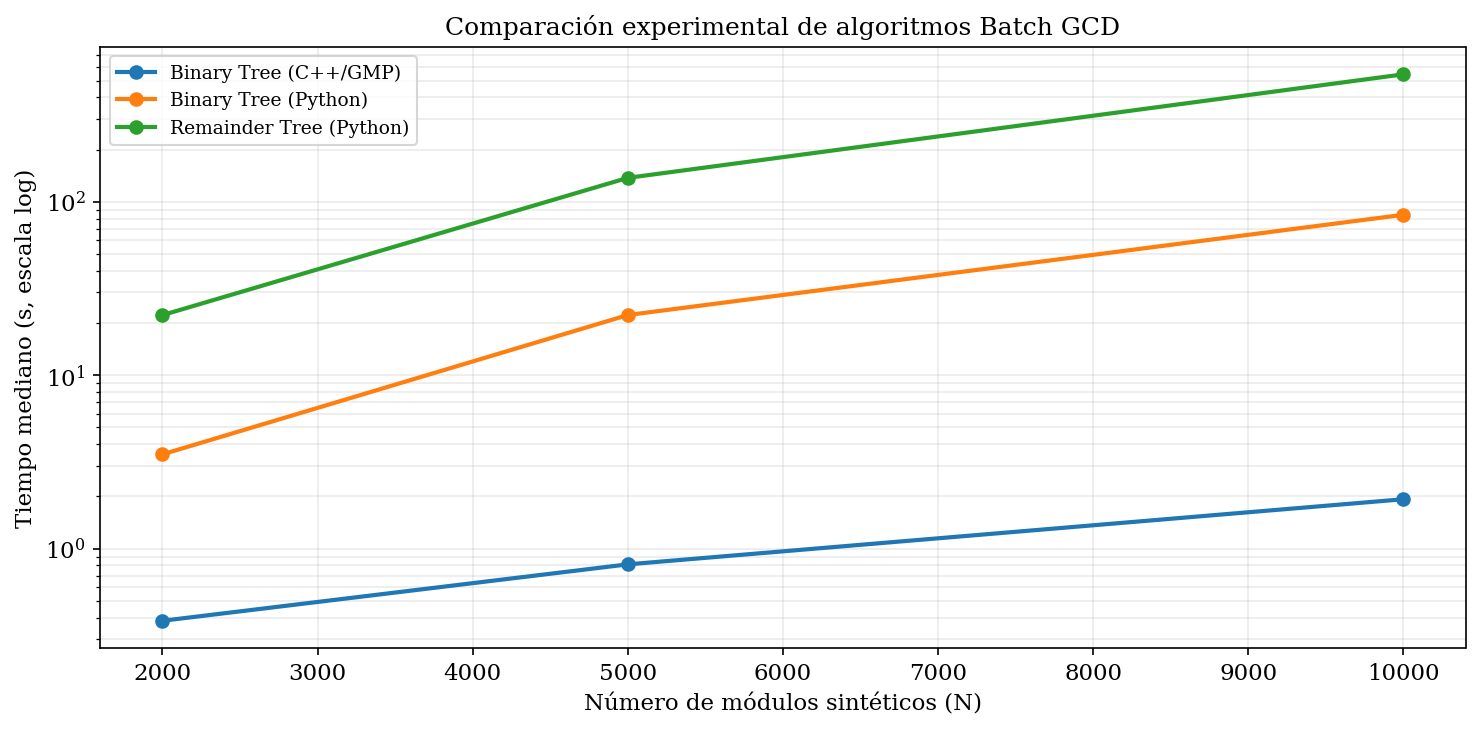

Figura guardada en: /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/resultados/benchmark/comparacion_algoritmos_benchmark.png


In [103]:
if df_benchmark.empty:
    print("Benchmark sintético omitido; esta celda no genera resultados.")
else:
    plt.figure(figsize=(10, 5))
    for algoritmo, group in completed_benchmark.groupby("Algoritmo"):
        aggregated = group.groupby("N", as_index=False)["Tiempo (s)"].median().sort_values("N")
        plt.plot(aggregated["N"], aggregated["Tiempo (s)"], marker="o", linewidth=2, label=algoritmo)

    plt.yscale("log")
    plt.xlabel("Número de módulos sintéticos (N)")
    plt.ylabel("Tiempo mediano (s, escala log)")
    plt.title("Comparación experimental de algoritmos Batch GCD")
    plt.grid(alpha=0.25, which="both")
    plt.legend()
    plt.tight_layout()

    algorithms_png = RESULTS_BENCHMARK_DIR / "comparacion_algoritmos_benchmark.png"
    plt.savefig(algorithms_png, dpi=200)
    plt.show()
    print(f"Figura guardada en: {algorithms_png}")


## Figuras de escalabilidad sintética

Para que el notebook recoja las figuras más útiles del artículo, se generan dos paneles `2 x 3`: filas para módulos RSA de 1024 y 2048 bits, y columnas para `WEAK = 2, 100, 1000`. Esta estructura reproduce la lectura principal del experimento de Pelofske, añadiendo la implementación C++/GMP propia.

Figura PDF guardada en: /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/resultados/benchmark/comparativa_tiempo_pelofske_extendida.pdf


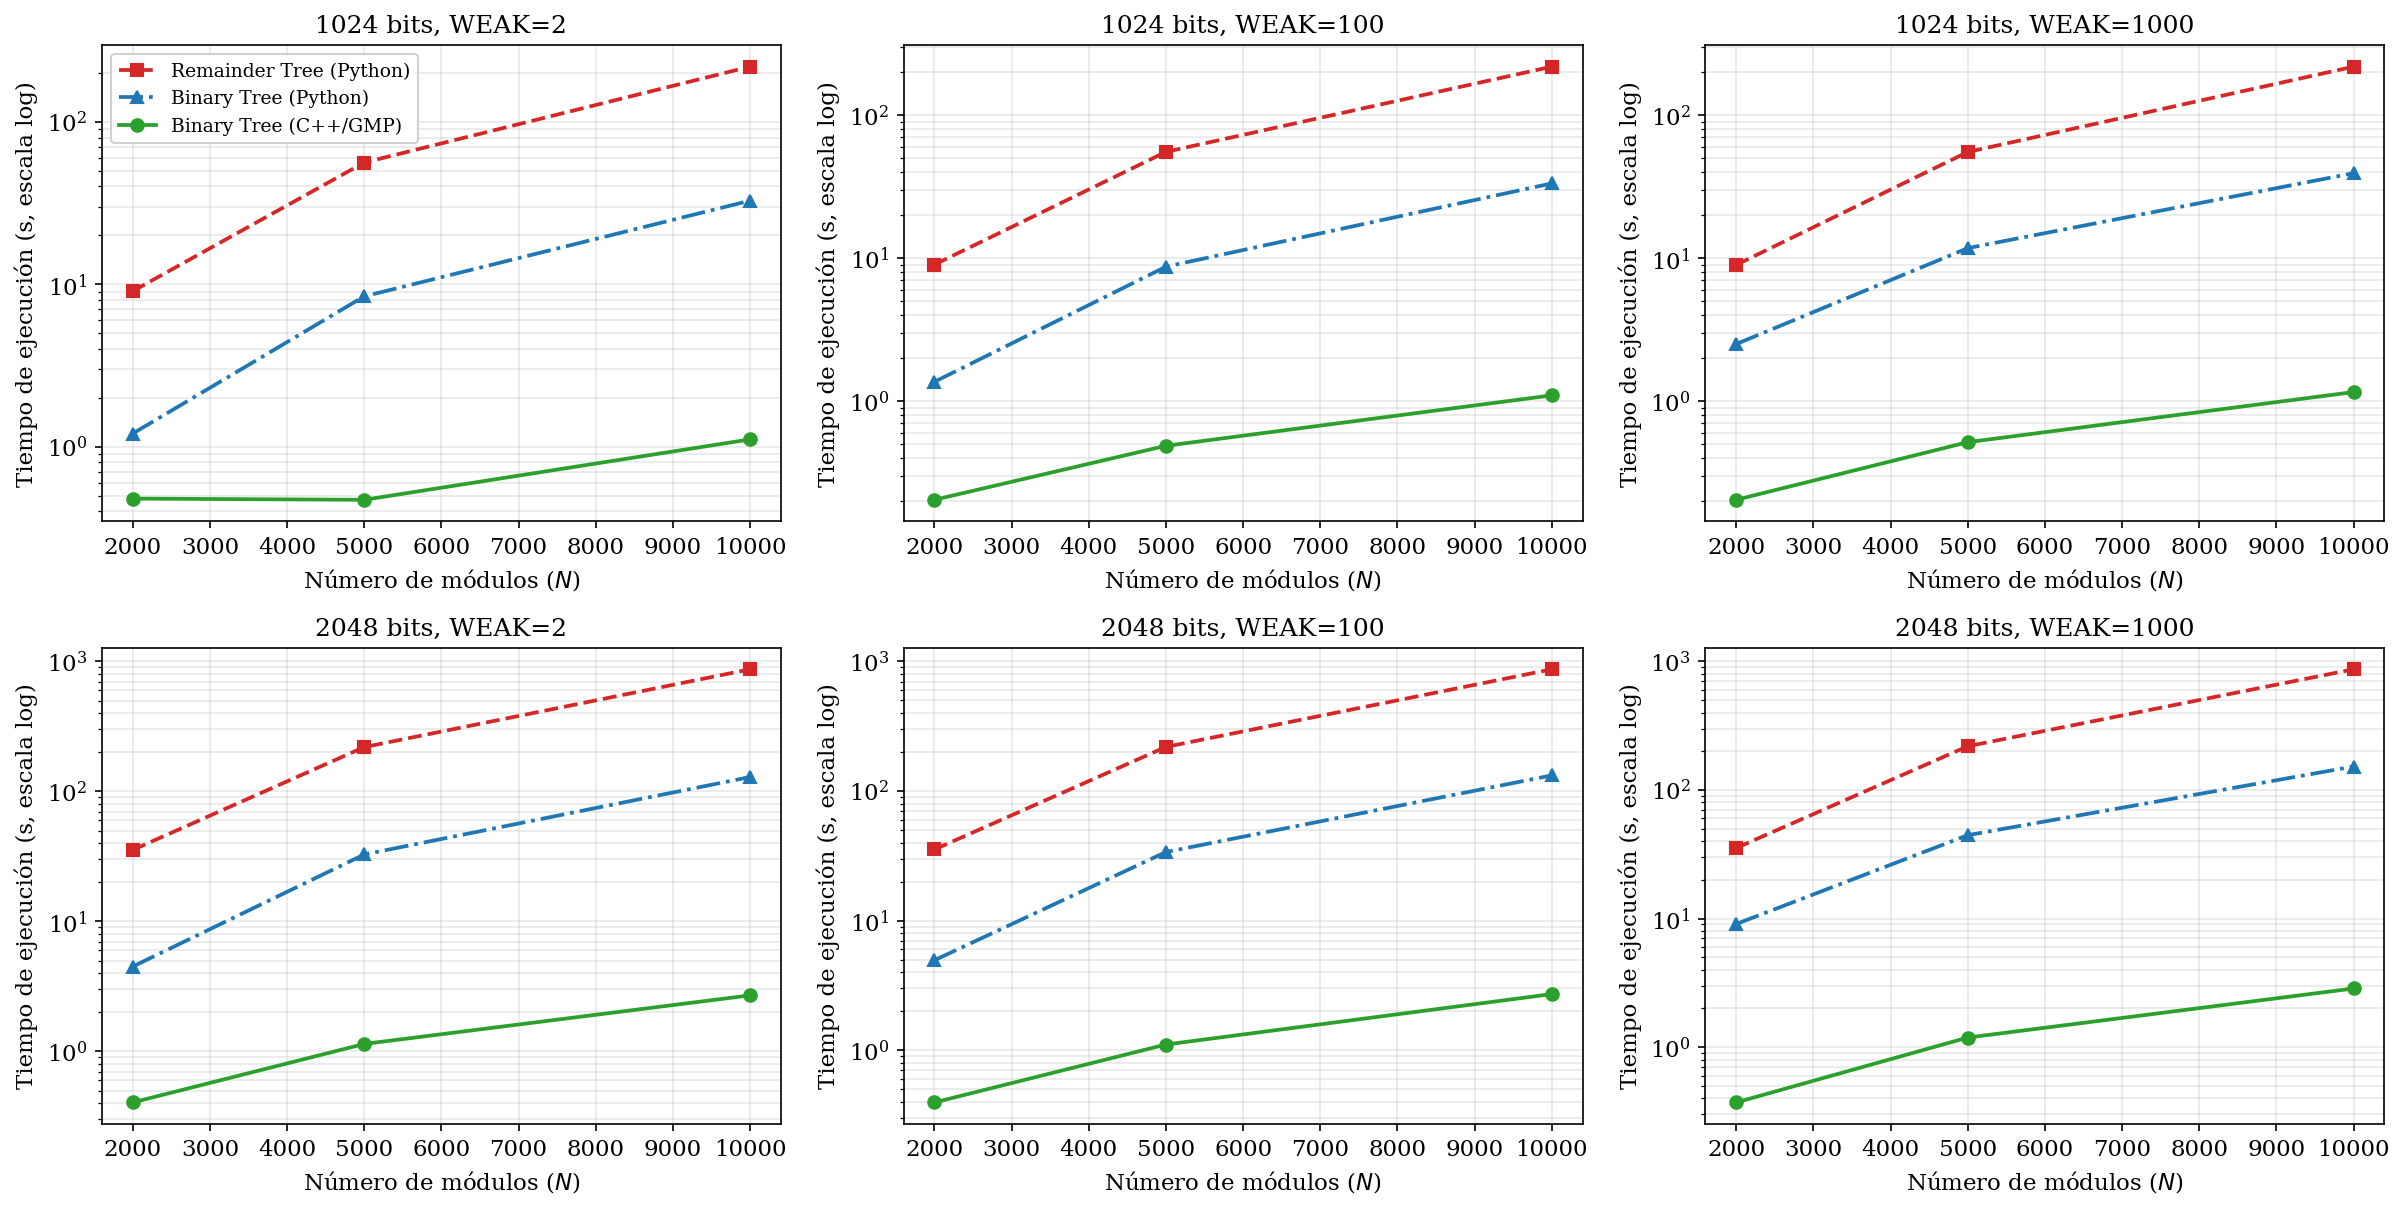

Figura guardada en: /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/resultados/benchmark/benchmark_tiempo_grid.png
Figura PDF guardada en: /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/resultados/benchmark/comparativa_memoria_pelofske_extendida.pdf


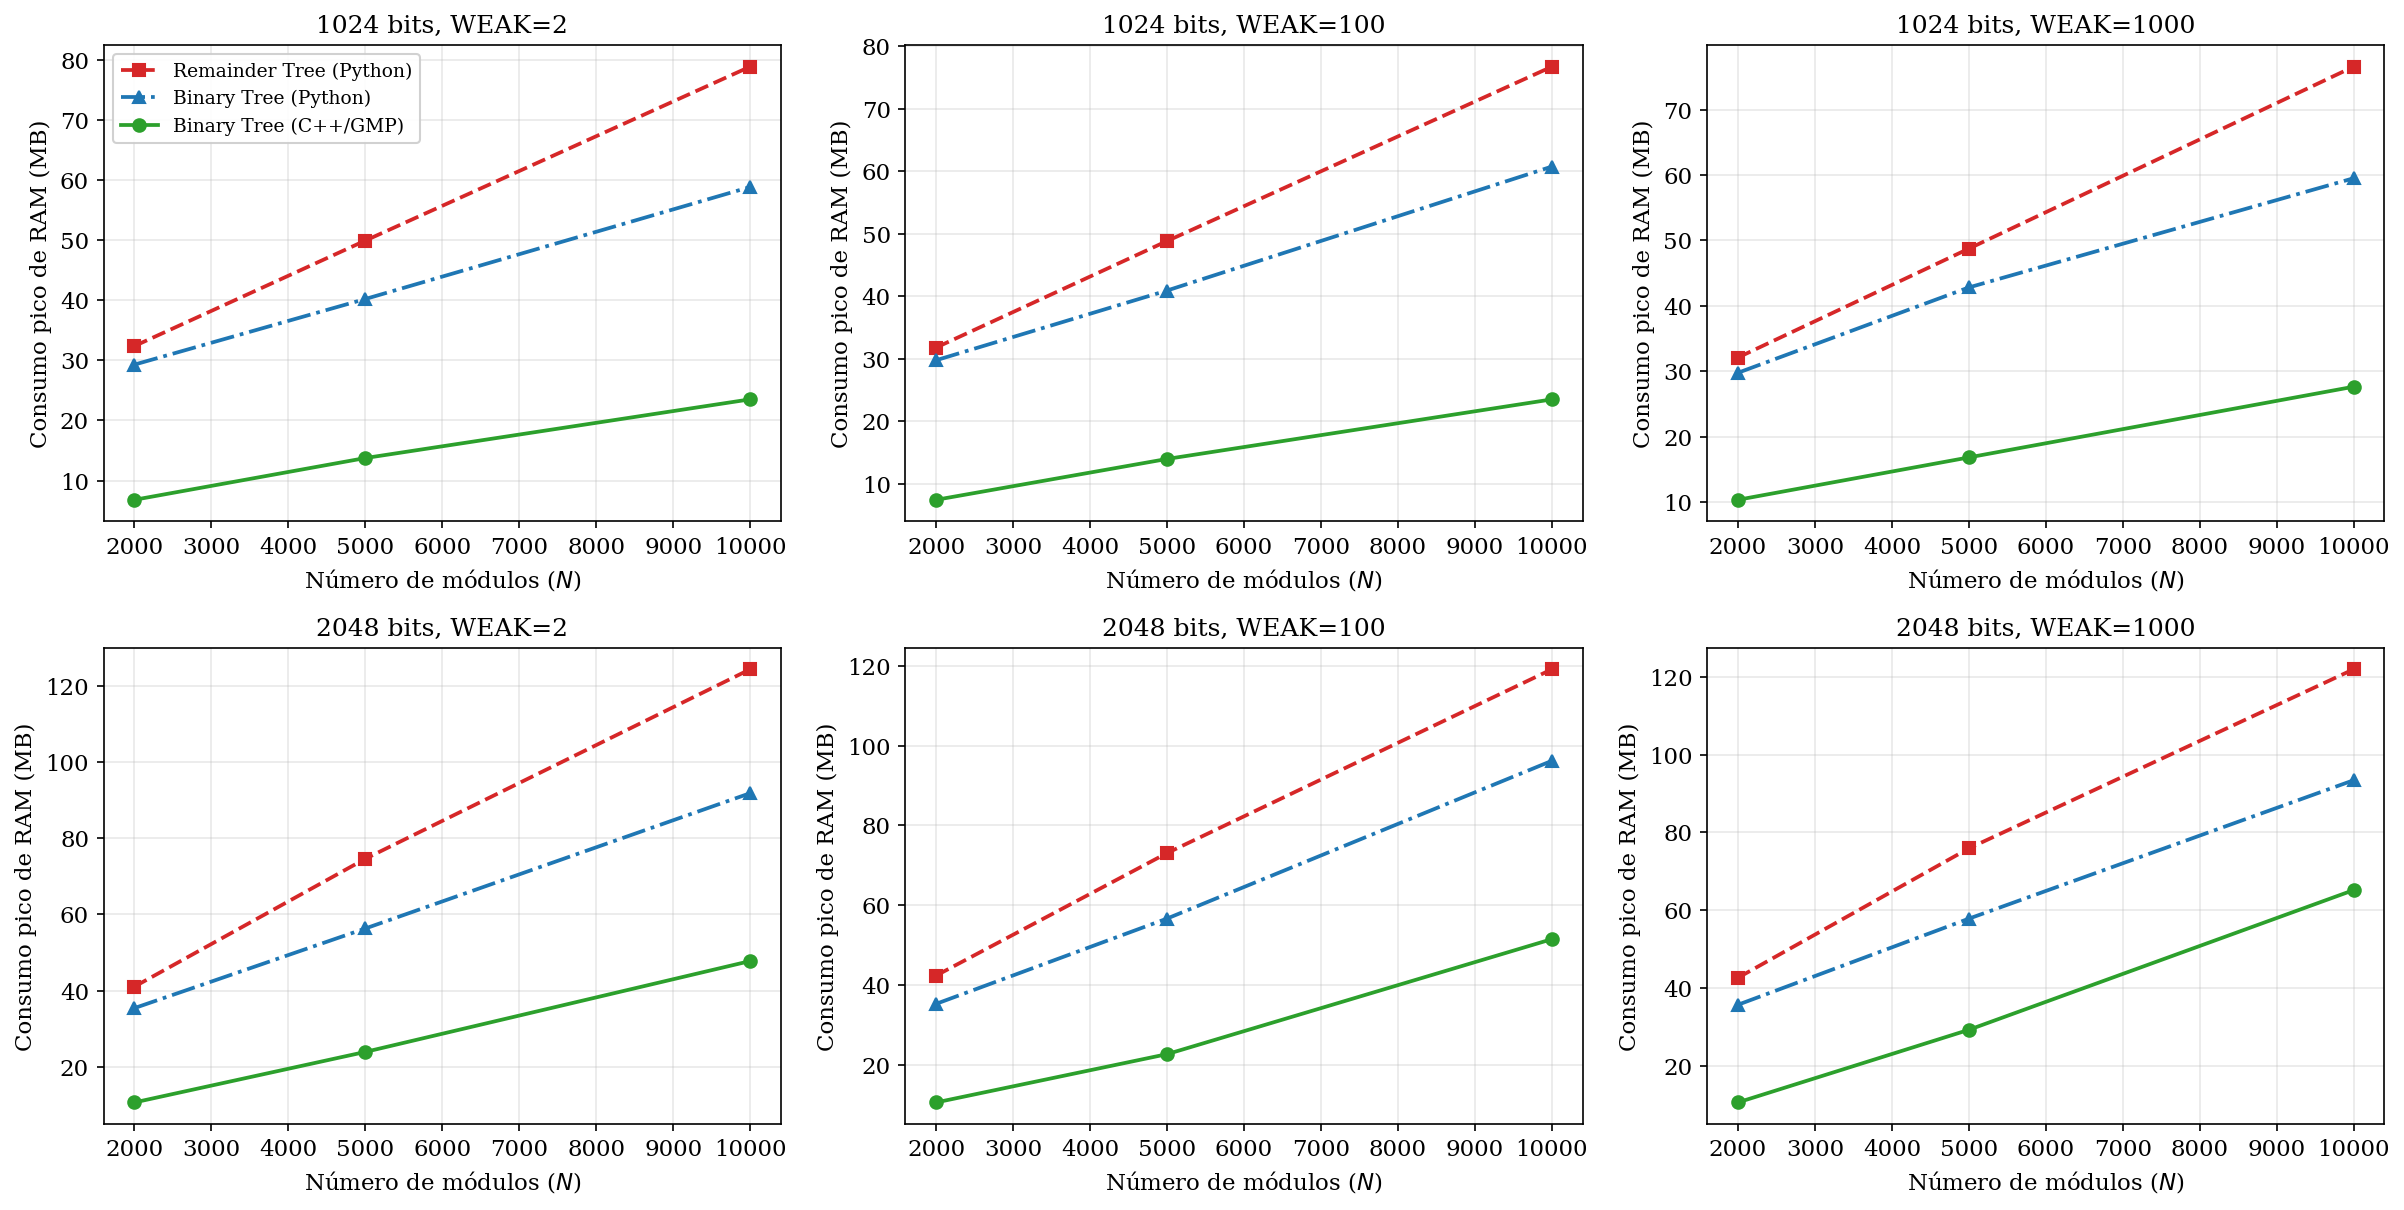

Figura guardada en: /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/resultados/benchmark/benchmark_memoria_grid.png


In [104]:
if df_benchmark.empty:
    print("Benchmark sintético omitido; esta celda no genera resultados.")
else:
    ALGO_STYLES = {
        "Remainder Tree (Python)": {"color": "#d62728", "marker": "s", "ls": "--"},
        "Binary Tree (Python)":    {"color": "#1f77b4", "marker": "^", "ls": "-."},
        "Binary Tree (C++/GMP)":   {"color": "#2ca02c", "marker": "o", "ls": "-"},
    }

    BITS_ORDER = sorted(df_benchmark["Bits"].dropna().unique())
    WEAK_ORDER = sorted(df_benchmark["WEAK"].dropna().unique())


    def plot_benchmark_grid(metric, ylabel, filename, log_scale=False):
        fig, axes = plt.subplots(
            len(BITS_ORDER),
            len(WEAK_ORDER),
            figsize=(5.4 * len(WEAK_ORDER), 4.1 * len(BITS_ORDER)),
            sharex=False,
            sharey=False,
        )

        if len(BITS_ORDER) == 1 and len(WEAK_ORDER) == 1:
            axes = [[axes]]
        elif len(BITS_ORDER) == 1:
            axes = [axes]
        elif len(WEAK_ORDER) == 1:
            axes = [[ax] for ax in axes]

        timeout_value = df_benchmark["Tiempo (s)"].dropna().max()

        for row, bits in enumerate(BITS_ORDER):
            for col, weak in enumerate(WEAK_ORDER):
                ax = axes[row][col]
                sub = df_benchmark[(df_benchmark["Bits"] == bits) & (df_benchmark["WEAK"] == weak)]

                for algo, sty in ALGO_STYLES.items():
                    s = sub[(sub["Algoritmo"] == algo) & (~sub["Timeout"])].dropna(subset=[metric]).sort_values("N")
                    if not s.empty:
                        ax.plot(
                            s["N"],
                            s[metric],
                            color=sty["color"],
                            marker=sty["marker"],
                            ls=sty["ls"],
                            lw=1.8,
                            ms=6,
                            label=algo,
                        )

                    if metric == "Tiempo (s)":
                        timeouts = sub[(sub["Algoritmo"] == algo) & (sub["Timeout"])]
                        if not timeouts.empty and timeout_value:
                            ax.scatter(timeouts["N"], [timeout_value] * len(timeouts), color=sty["color"], marker="x", s=70)

                if log_scale:
                    ax.set_yscale("log")

                ax.set_title(f"{bits} bits, WEAK={weak}")
                ax.set_xlabel(r"Número de módulos ($N$)")
                ax.set_ylabel(ylabel)
                ax.grid(True, which="both" if log_scale else "major", alpha=0.28)
                ax.ticklabel_format(axis="x", style="plain")
                if row == 0 and col == 0:
                    ax.legend(loc="upper left", framealpha=0.9)

        plt.tight_layout()
        out = RESULTS_BENCHMARK_DIR / filename
        fig.savefig(out, dpi=200, bbox_inches="tight")

        pdf_aliases = {
            "benchmark_tiempo_grid.png": "comparativa_tiempo_pelofske_extendida.pdf",
            "benchmark_memoria_grid.png": "comparativa_memoria_pelofske_extendida.pdf",
        }
        if filename in pdf_aliases:
            pdf_out = RESULTS_BENCHMARK_DIR / pdf_aliases[filename]
            fig.savefig(pdf_out, bbox_inches="tight")
            print(f"Figura PDF guardada en: {pdf_out}")

        plt.show()
        print(f"Figura guardada en: {out}")


    plot_benchmark_grid("Tiempo (s)", "Tiempo de ejecución (s, escala log)", "benchmark_tiempo_grid.png", log_scale=True)
    plot_benchmark_grid("RAM pico (MB)", "Consumo pico de RAM (MB)", "benchmark_memoria_grid.png", log_scale=False)


## Speedup de Binary Tree frente a Remainder Tree

Además del tiempo absoluto, el speedup permite resumir la mejora relativa. Esta figura es útil para la memoria porque conecta directamente la comparación experimental con la decisión de usar la implementación C++/GMP sobre los datos reales.

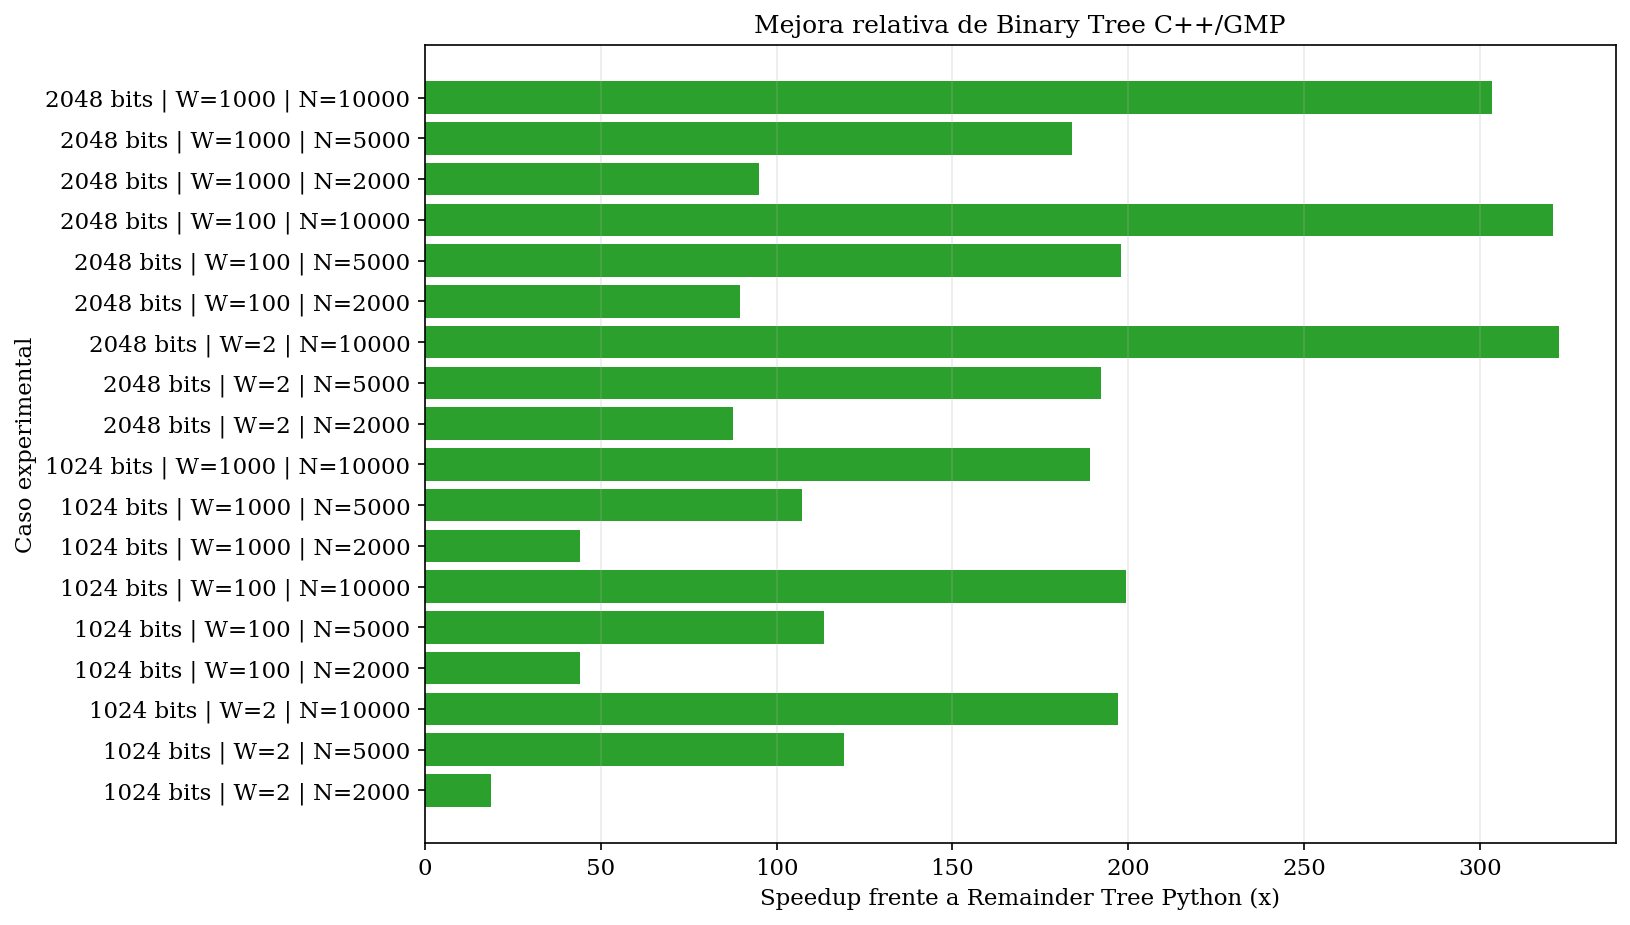

Figura guardada en: /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/resultados/benchmark/benchmark_speedup_cpp.png


In [105]:
if df_benchmark.empty:
    print("Benchmark sintético omitido; esta celda no genera resultados.")
else:
    if not df_benchmark_summary.empty and "Speedup Binary Tree (C++/GMP)" in df_benchmark_summary.columns:
        df_speedup_plot = df_benchmark_summary.copy()
        df_speedup_plot["Caso"] = (
            df_speedup_plot["Bits"].astype(str)
            + " bits | W=" + df_speedup_plot["WEAK"].astype(str)
            + " | N=" + df_speedup_plot["N"].astype(str)
        )

        plt.figure(figsize=(11, max(5, 0.35 * len(df_speedup_plot))))
        plt.barh(df_speedup_plot["Caso"], df_speedup_plot["Speedup Binary Tree (C++/GMP)"], color="#2ca02c")
        plt.xlabel("Speedup frente a Remainder Tree Python (x)")
        plt.ylabel("Caso experimental")
        plt.title("Mejora relativa de Binary Tree C++/GMP")
        plt.grid(axis="x", alpha=0.25)
        plt.tight_layout()

        speedup_png = RESULTS_BENCHMARK_DIR / "benchmark_speedup_cpp.png"
        plt.savefig(speedup_png, dpi=200, bbox_inches="tight")
        plt.show()
        print(f"Figura guardada en: {speedup_png}")
    else:
        print("No hay columnas de speedup suficientes para generar la figura.")


# Ataque final sobre CT Logs reales

Una vez justificada la implementación C++/GMP mediante el benchmark, se consolida el conjunto de módulos RSA reales extraídos de CT Logs. El objetivo es atacar el conjunto deduplicado final, no repetir el benchmark sobre datos reales con las versiones Python.

La versión limpia del repositorio usa como entrada principal `Datos/modulos.txt`, que contiene un módulo RSA hexadecimal por línea después de normalizar y deduplicar las extracciones.


In [106]:
def read_moduli(path):
    path = Path(path)
    if not path.exists():
        return set()
    moduli = set()
    with path.open("r", encoding="utf-8", errors="replace") as f:
        for line in f:
            value = line.strip().upper()
            if value and HEX_RE.fullmatch(value):
                moduli.add(value)
    return moduli


def read_moduli_from_parts(log_dir):
    log_dir = Path(log_dir)
    moduli = set()
    issuer_pairs = set()
    for part in sorted((log_dir / "parts").glob("modulus_*.txt")):
        current = None
        with part.open("r", encoding="utf-8", errors="replace") as f:
            for line in f:
                line = line.strip()
                if line.startswith("Modulus="):
                    current = line[len("Modulus="):].strip().upper()
                elif line.startswith("issuer=") and current and HEX_RE.fullmatch(current):
                    issuer = line[len("issuer="):].strip()
                    moduli.add(current)
                    issuer_pairs.add((current, issuer))
                    current = None
    return moduli, issuer_pairs


def count_lines(path):
    path = Path(path)
    if not path.exists():
        return 0
    with path.open("r", encoding="utf-8", errors="replace") as f:
        return sum(1 for line in f if line.strip())


def write_moduli(path, moduli):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        for value in sorted(moduli):
            f.write(value + "\n")
    return path


## Descarga y extracción de módulos desde CT Logs

La descarga masiva de CT Logs no se ejecuta automáticamente desde el notebook porque implica cientos de ZIPs y un volumen elevado de datos temporales. En su lugar, esta sección documenta el procedimiento seguido y carga los ficheros ligeros que conservan la trazabilidad: lista de logs, URLs seleccionadas, resumen de extracción y conjunto final deduplicado.

Los enlaces proceden del repositorio público `geomys/ct-archive`. Se usaron los logs útiles que disponían de ZIPs accesibles y que contenían el directorio `issuer/`, ya que esos certificados permiten extraer módulos RSA de claves públicas de emisores. Los ZIPs brutos se procesaron de forma incremental y se eliminaron después de extraer los módulos para evitar almacenar innecesariamente decenas o cientos de GB.


In [107]:
CT_ARCHIVE_LOGS_FILE = DATOS_DIR / "ct_archive_logs_seleccionados.txt"
CT_ARCHIVE_LOGS_SUMMARY = DATOS_DIR / "ct_archive_logs_seleccionados.csv"
CT_ARCHIVE_EXTRACTION_SUMMARY = DATOS_DIR / "resumen_extraccion_ct_archive.csv"
CT_ARCHIVE_EXTRACTION_REPORT = DATOS_DIR / "informe_extraccion_ct_archive.md"

ct_archive_urls = []
if CT_ARCHIVE_URLS_FILE.exists():
    with CT_ARCHIVE_URLS_FILE.open("r", encoding="utf-8", errors="replace") as f:
        ct_archive_urls = [line.strip() for line in f if line.strip() and not line.startswith("#")]

ct_archive_logs = []
if CT_ARCHIVE_LOGS_FILE.exists():
    with CT_ARCHIVE_LOGS_FILE.open("r", encoding="utf-8", errors="replace") as f:
        ct_archive_logs = [line.strip() for line in f if line.strip() and not line.startswith("#")]

print(f"Repositorio de enlaces: {CT_ARCHIVE_REPO}")
print(f"Logs seleccionados:     {len(ct_archive_logs)}")
print(f"URLs ZIP registradas:   {len(ct_archive_urls)}")
print(f"Resumen de extracción:  {CT_ARCHIVE_EXTRACTION_SUMMARY}")


Repositorio de enlaces: https://github.com/geomys/ct-archive
Logs seleccionados:     23
URLs ZIP registradas:   706
Resumen de extracción:  /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/Datos/resumen_extraccion_ct_archive.csv


### Esquema operativo utilizado

El procedimiento operativo fue el siguiente:

1. Seleccionar en `geomys/ct-archive` los logs con ZIPs accesibles y no marcados como demasiado grandes para Internet Archive.
2. Descargar los ZIPs de cada log con reanudación (`curl -C -`) y paralelismo controlado.
3. Inspeccionar cada ZIP y conservar únicamente entradas bajo `issuer/`.
4. Ejecutar OpenSSL sobre cada certificado de issuer para obtener `Modulus=` e `issuer=`.
5. Normalizar los módulos a hexadecimal, eliminar líneas no RSA y deduplicar con `sort -u`.
6. Unificar los módulos de todos los logs con las fuentes previas recibidas y guardar el conjunto final en `Datos/modulos.txt`.

La deduplicación se realiza en dos niveles: primero dentro de cada log y después sobre el conjunto global. De esta forma, un mismo módulo visto en varios certificados, logs o fuentes solo aparece una vez en el ataque Batch GCD final.


### Comandos base usados

En los ZIPs de `ct-archive`, el directorio `issuer/` contiene certificados X.509 de emisores usados por el log. Como el objetivo de esta fase es contar y analizar módulos RSA de emisores, no es necesario recorrer `tile/` ni todas las entradas del log. Esta decisión reduce mucho el volumen de datos que se descarga y procesa.

El punto de partida fue el bucle propuesto por Domingo para una carpeta que ya contiene certificados sueltos:

```bash
for i in $(ls); do
  openssl x509 -noout -modulus -issuer -in "$i" \
    | grep -E "^Modulus=[^N]"
done >> modulus.txt
```

Ese bucle funciona si todos los ficheros son certificados legibles por `openssl x509`, pero se adaptó para evitar problemas con nombres de fichero, controlar errores y soportar certificados DER y PEM.

Para un único ZIP:

```bash
mkdir -p issuers_extraidos
unzip -q 000.zip 'issuer/*' -d issuers_extraidos

find issuers_extraidos -type f | while read -r cert; do
  openssl x509 -inform DER -noout -modulus -issuer -in "$cert" 2>/dev/null \
  || openssl x509 -inform PEM -noout -modulus -issuer -in "$cert" 2>/dev/null \
  || true
done | grep -E '^Modulus=[^N]' >> modulus.txt
```

Para muchos ZIPs:

```bash
mkdir -p issuers_extraidos
: > modulus.txt

for zip in *.zip; do
  echo "Procesando $zip"
  rm -rf issuers_extraidos
  mkdir -p issuers_extraidos

  unzip -q "$zip" 'issuer/*' -d issuers_extraidos

  find issuers_extraidos -type f | while read -r cert; do
    openssl x509 -inform DER -noout -modulus -issuer -in "$cert" 2>/dev/null \
    || openssl x509 -inform PEM -noout -modulus -issuer -in "$cert" 2>/dev/null \
    || true
  done | grep -E '^Modulus=[^N]' >> modulus.txt
done
```

Para hacerlo compatible con el formato de entrada usado en scripts previos, se puede convertir la salida de OpenSSL:

```bash
sed -n 's/^Modulus=/Modulus: /p' modulus.txt > total_certificados.txt
python3 extract_moduli.py total_certificados.txt moduli_hex.txt
```

En la práctica, para el ataque Batch GCD basta con obtener directamente los módulos únicos en hexadecimal:

```bash
sed -n 's/^Modulus=//p' modulus.txt \
  | tr '[:lower:]' '[:upper:]' \
  | sort -u > moduli_hex.txt
```

En las ejecuciones con paralelismo se usaron salidas parciales por ZIP para evitar que varios procesos escribieran simultáneamente en el mismo `modulus.txt`. Después se combinaron todas las partes:

```bash
cat parts/modulus_*.txt > modulus.txt
sed -n 's/^Modulus=//p' modulus.txt \
  | tr '[:lower:]' '[:upper:]' \
  | sort -u > moduli_hex.txt
```

Punto importante: algunos logs del repositorio aparecen marcados con `†`; el propio repositorio indica que fueron archivados sin directorio `issuer/`. Esos logs no sirven para esta vía rápida basada en certificados de emisores. Procesarlos exigiría recorrer las hojas `tile/`, que es un problema distinto y bastante más costoso.


### Incidencias con ZIPs grandes y Zip64

Durante la extracción se prestó atención especial a los ZIPs grandes. Algunos ficheros podían aparecer inicialmente como `no_issuer` no porque faltara realmente el directorio `issuer/`, sino porque la descarga estaba incompleta o porque el ZIP no podía inspeccionarse correctamente. Además, el propio README de `geomys/ct-archive` advierte de problemas relacionados con Zip64 en algunos archivos generados, por lo que no se asumió que un fallo de `unzip` equivaliera automáticamente a ausencia de emisores.

Por este motivo, los ZIPs sospechosos se conservaron o redescargaron y se reprocesaron de forma conservadora. En particular, se creó una tanda específica de revisión para `ct_sectigo_elephant2025h2` y `ct_sectigo_tiger2025h2`, ya que presentaban ZIPs grandes con comportamiento distinto al resto. Esta revisión evitó descartar módulos por un problema de formato o descarga y permitió cerrar la extracción distinguiendo entre ZIPs realmente sin `issuer/` y ZIPs que requerían reprocesado.


In [108]:
if CT_ARCHIVE_EXTRACTION_SUMMARY.exists():
    df_extraction_raw = pd.read_csv(CT_ARCHIVE_EXTRACTION_SUMMARY)
else:
    df_extraction_raw = pd.DataFrame(columns=[
        "log", "zips_disponibles", "zips_procesados", "zips_sin_issuer", "zips_fallidos",
        "pares_modulo_issuer", "modulos_unicos",
    ])

column_map = {
    "log": "Log",
    "zips_disponibles": "ZIPs totales",
    "zips_procesados": "ZIPs procesados",
    "zips_sin_issuer": "ZIPs sin issuer",
    "zips_fallidos": "ZIPs fallidos",
    "pares_modulo_issuer": "Pares módulo-issuer desde parts",
    "modulos_unicos": "Módulos únicos",
}

df_logs = df_extraction_raw.rename(columns=column_map).copy()
for column in ["ZIPs totales", "ZIPs procesados", "ZIPs sin issuer", "ZIPs fallidos", "Pares módulo-issuer desde parts", "Módulos únicos"]:
    if column not in df_logs.columns:
        df_logs[column] = 0

df_logs["ZIPs pendientes"] = (df_logs["ZIPs totales"] - df_logs["ZIPs procesados"] - df_logs["ZIPs sin issuer"] - df_logs["ZIPs fallidos"]).clip(lower=0)
df_logs["Completo"] = df_logs["ZIPs pendientes"].eq(0)
df_logs["Módulos únicos desde parts"] = df_logs["Módulos únicos"]

logs_csv = RESULTS_CTLOGS_DIR / "estado_extraccion_logs.csv"
df_logs.to_csv(logs_csv, index=False)

display(df_logs)
print(f"Logs resumidos: {len(df_logs)}")
print(f"ZIPs procesados con issuer: {int(df_logs['ZIPs procesados'].sum())}")
print(f"ZIPs sin issuer: {int(df_logs['ZIPs sin issuer'].sum())}")
print(f"Módulos únicos por log, sin deduplicación global: {int(df_logs['Módulos únicos'].sum()):,}".replace(",", "."))
print(f"Resumen normalizado guardado en: {logs_csv}")


,Log,ZIPs totales,ZIPs procesados,ZIPs sin issuer,ZIPs fallidos,Pares módulo-issuer desde parts,Módulos únicos,ZIPs pendientes,Completo,Módulos únicos desde parts
0,ct_digicert_yeti2025,118,118,0,0,474084,3902,0,True,3902
1,ct_digicert_nessie2025,53,53,0,0,184236,3408,0,True,3408
2,ct_digicert_sphinx2024h1,1,1,0,0,360,350,0,True,350
3,ct_digicert_sphinx2024h2,2,2,0,0,5762,2823,0,True,2823
4,ct_digicert_sphinx2025h1,17,17,0,0,50720,3087,0,True,3087
5,ct_digicert_wyvern2024h1,1,1,0,0,359,348,0,True,348
6,ct_digicert_wyvern2024h2,2,2,0,0,5524,2704,0,True,2704
7,ct_digicert_wyvern2025h1,17,17,0,0,50800,3092,0,True,3092
8,ct_letsencrypt_oak2025h1,60,60,0,0,319920,5211,0,True,5211
9,ct_letsencrypt_oak2026h1,36,36,0,0,134856,3653,0,True,3653


Logs resumidos: 20
ZIPs procesados con issuer: 628
ZIPs sin issuer: 16
Módulos únicos por log. sin deduplicación global: 63.041
Resumen normalizado guardado en: /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/resultados/ctlogs/estado_extraccion_logs.csv


In [109]:
source_rows = []
global_moduli = set()

def add_source(label, path, moduli):
    before = len(global_moduli)
    global_moduli.update(moduli)
    source_rows.append({
        "Fuente": label,
        "Ruta": str(path),
        "Módulos en fuente": len(moduli),
        "Nuevos aportados": len(global_moduli) - before,
        "Duplicados frente a acumulado": len(moduli) - (len(global_moduli) - before),
    })

CLEAN_GLOBAL_FILES = [
    DATOS_DIR / "modulos.txt",
    DATOS_DIR / "moduli_hex_final_principal.txt",
    DATOS_DIR / "modulos_rsa_unicos_total_certificados.txt",
]

for path in CLEAN_GLOBAL_FILES:
    if path.exists():
        add_source(path.name, path, read_moduli(path))

if not global_moduli:
    raise RuntimeError("No se encontró ningún fichero de módulos RSA. Añade un fichero en Datos/modulos.txt.")

df_sources = pd.DataFrame(source_rows)
sources_csv = RESULTS_CTLOGS_DIR / "fuentes_modulos_consolidados.csv"
df_sources.to_csv(sources_csv, index=False)

RAW_MODULI = RESULTS_CTLOGS_DIR / "moduli_hex_final_bruto.txt"
FINAL_MODULI = RESULTS_CTLOGS_DIR / "moduli_hex_final_principal.txt"
write_moduli(RAW_MODULI, global_moduli)

quality_rows = []
valid_moduli = set()
for value in sorted(global_moduli):
    n = int(value, 16)
    bit_length = n.bit_length()
    reasons = []
    if bit_length < 1024:
        reasons.append("bits<1024")
    if n % 2 == 0:
        reasons.append("par")

    is_plausible_rsa = not reasons
    if is_plausible_rsa:
        valid_moduli.add(value)

    quality_rows.append({
        "Modulo": value,
        "Bits": bit_length,
        "Par": n % 2 == 0,
        "RSA plausible": is_plausible_rsa,
        "Motivo descarte": ";".join(reasons),
    })

df_moduli_quality = pd.DataFrame(quality_rows)
quality_csv = RESULTS_CTLOGS_DIR / "validacion_modulos.csv"
df_moduli_quality.to_csv(quality_csv, index=False)

rejected_moduli = df_moduli_quality.loc[~df_moduli_quality["RSA plausible"]].copy()
rejected_csv = RESULTS_CTLOGS_DIR / "modulos_descartados.csv"
rejected_moduli.to_csv(rejected_csv, index=False)

write_moduli(FINAL_MODULI, valid_moduli)

display(df_sources)
print(f"Módulos únicos brutos: {len(global_moduli):,}".replace(",", "."))
print(f"Módulos RSA plausibles para el ataque: {len(valid_moduli):,}".replace(",", "."))
print(f"Módulos descartados en validación: {len(rejected_moduli):,}".replace(",", "."))
print(f"Conjunto bruto guardado en: {RAW_MODULI}")
print(f"Conjunto filtrado guardado en: {FINAL_MODULI}")
print(f"Validación guardada en: {quality_csv}")
if not rejected_moduli.empty:
    display(rejected_moduli[["Bits", "Par", "Motivo descarte", "Modulo"]])


,Fuente,Ruta,Módulos en fuente,Nuevos aportados,Duplicados frente a acumulado
0,modulos.txt,/Users/davidquinza/Desktop/Máster Data Scienc...,54278,54278,0
1,modulos_rsa_unicos_total_certificados.txt,/Users/davidquinza/Desktop/Máster Data Scienc...,601,0,601


Módulos únicos brutos: 54.278
Módulos RSA plausibles para el ataque: 54.275
Módulos descartados en validación: 3
Conjunto bruto guardado en: /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/resultados/ctlogs/moduli_hex_final_bruto.txt
Conjunto filtrado guardado en: /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/resultados/ctlogs/moduli_hex_final_principal.txt
Validación guardada en: /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/resultados/ctlogs/validacion_modulos.csv


,Bits,Par,Motivo descarte,Modulo
3523,2024,True,par,9381018EF7CBD9FDE189BCD2477704BCC451D689B15FF9...
18186,1220,True,par,ADCF383690F10B309D5561DD22BDD8311B9264E8E51E36...
50164,992,False,bits<1024,E3769A5DF2711B932D06E81338A857A5BB24A703F42F44...


## Figuras de extracción y consolidación

Estas figuras resumen la parte de ingeniería de datos del TFM: qué logs aportan módulos, qué parte de la extracción queda pendiente y qué fuentes aumentan realmente el conjunto deduplicado. Son complementarias al ataque criptográfico porque justifican el tamaño final del conjunto analizado.

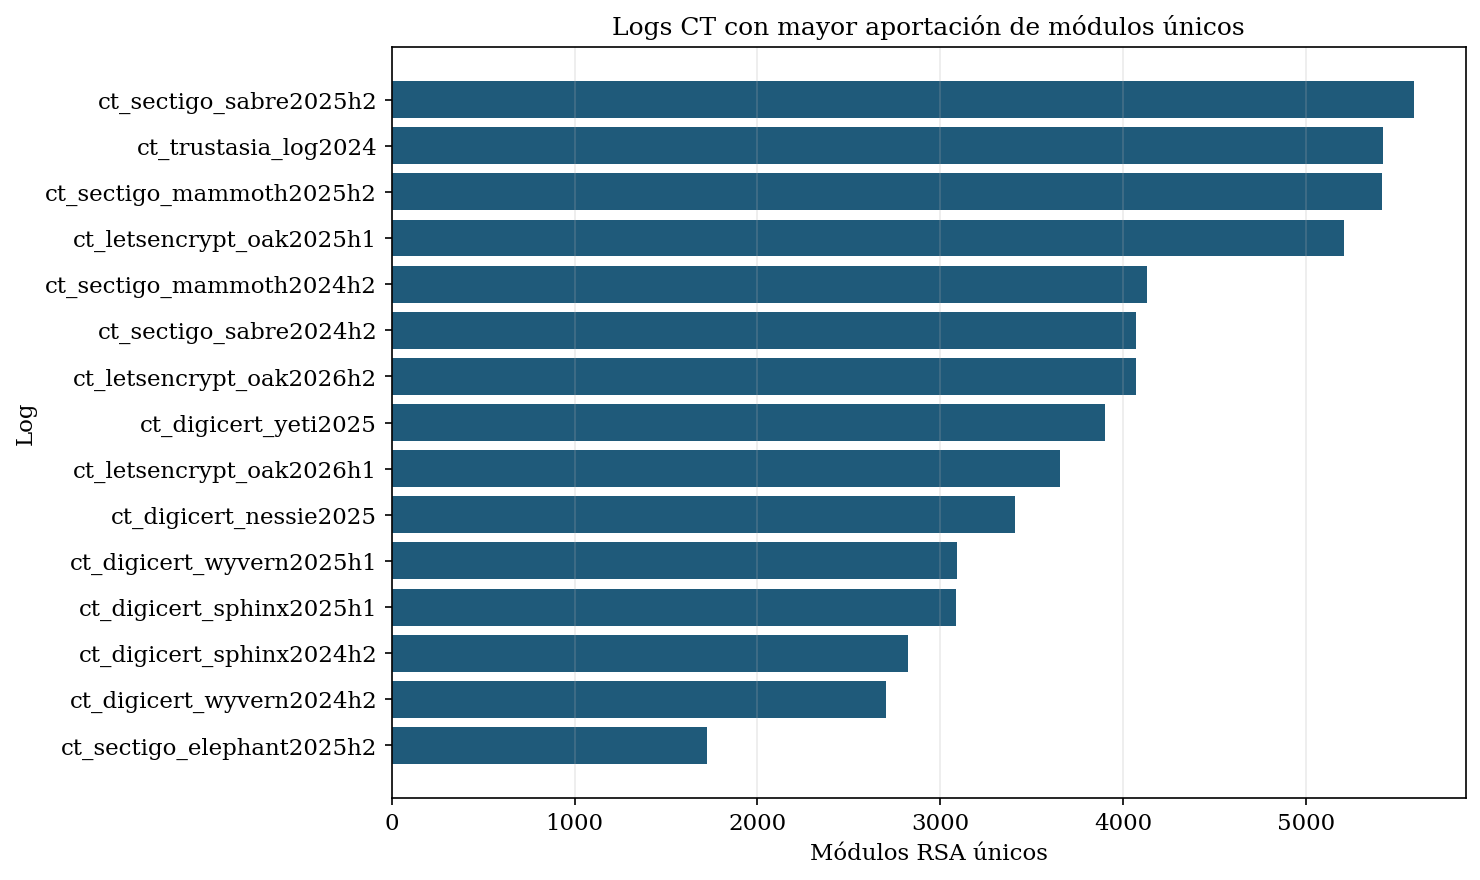

Figura guardada en: /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/resultados/ctlogs/ctlogs_top_modulos.png


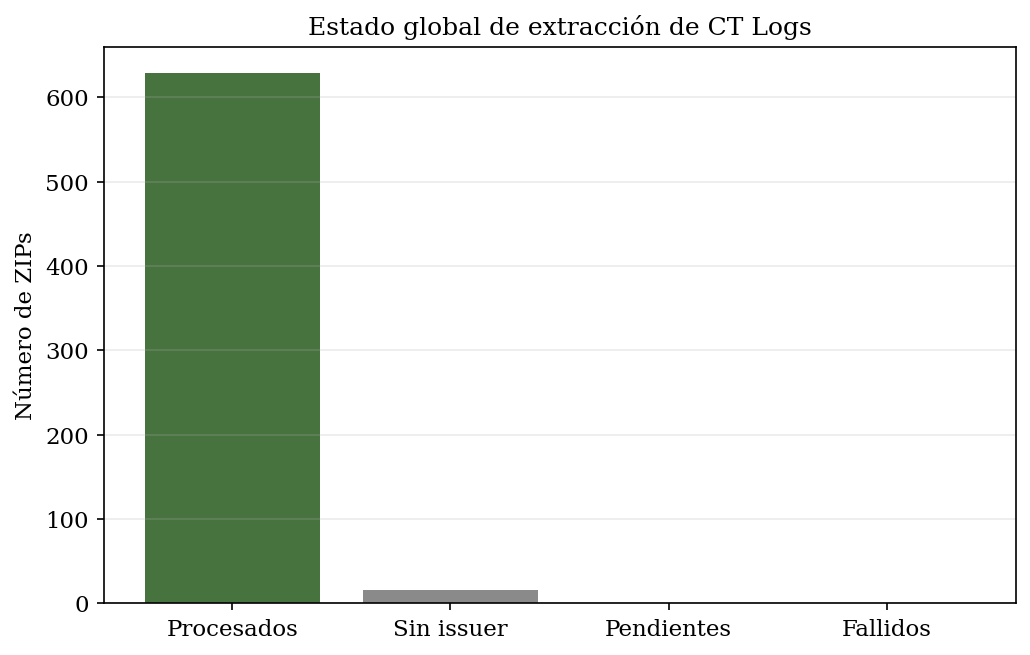

Figura guardada en: /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/resultados/ctlogs/ctlogs_estado_extraccion.png


In [110]:
if df_logs.empty:
    print("No se generan figuras de estado por log porque la versión limpia no incluye logs brutos de extracción.")
else:
    top_logs = df_logs[df_logs["Módulos únicos"] > 0].sort_values("Módulos únicos", ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    plt.barh(top_logs["Log"][::-1], top_logs["Módulos únicos"][::-1], color="#1f5a7a")
    plt.xlabel("Módulos RSA únicos")
    plt.ylabel("Log")
    plt.title("Logs CT con mayor aportación de módulos únicos")
    plt.grid(axis="x", alpha=0.25)
    plt.tight_layout()

    top_logs_png = RESULTS_CTLOGS_DIR / "ctlogs_top_modulos.png"
    plt.savefig(top_logs_png, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Figura guardada en: {top_logs_png}")

    status_totals = pd.Series({
        "Procesados": df_logs["ZIPs procesados"].sum(),
        "Sin issuer": df_logs["ZIPs sin issuer"].sum(),
        "Pendientes": df_logs["ZIPs pendientes"].sum(),
        "Fallidos": df_logs["ZIPs fallidos"].sum(),
    })

    plt.figure(figsize=(7, 4.5))
    plt.bar(status_totals.index, status_totals.values, color=["#47733f", "#8a8a8a", "#d2872c", "#b33a3a"])
    plt.ylabel("Número de ZIPs")
    plt.title("Estado global de extracción de CT Logs")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()

    status_png = RESULTS_CTLOGS_DIR / "ctlogs_estado_extraccion.png"
    plt.savefig(status_png, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Figura guardada en: {status_png}")


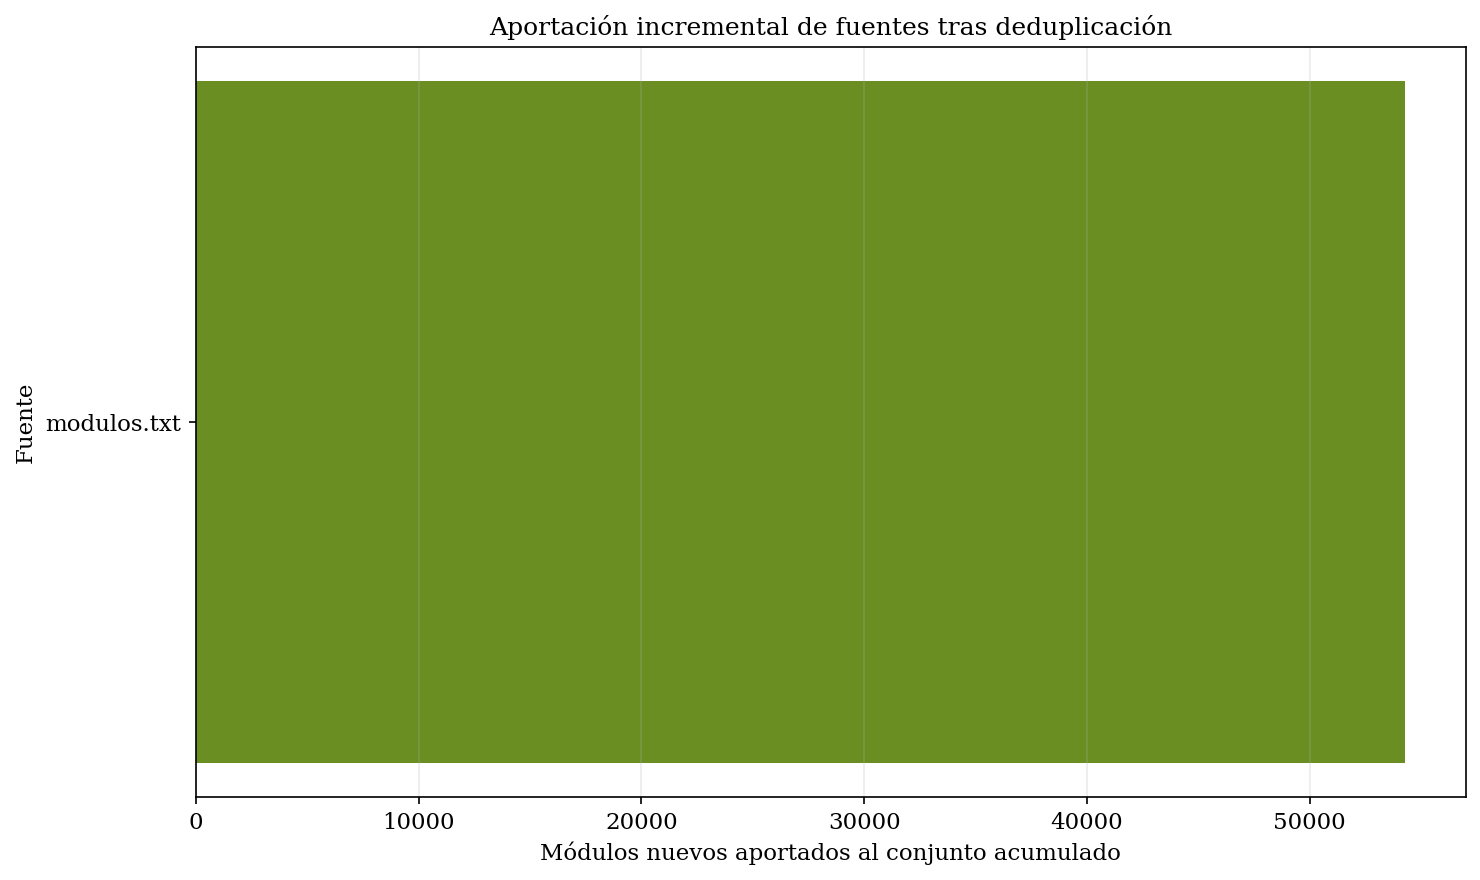

Figura guardada en: /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/resultados/ctlogs/fuentes_aportacion_incremental.png


In [111]:
# Aportación incremental de cada fuente al conjunto deduplicado.
contrib = df_sources[df_sources["Nuevos aportados"] > 0].copy()
contrib = contrib.sort_values("Nuevos aportados", ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(contrib["Fuente"][::-1], contrib["Nuevos aportados"][::-1], color="#6b8e23")
plt.xlabel("Módulos nuevos aportados al conjunto acumulado")
plt.ylabel("Fuente")
plt.title("Aportación incremental de fuentes tras deduplicación")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()

sources_png = RESULTS_CTLOGS_DIR / "fuentes_aportacion_incremental.png"
plt.savefig(sources_png, dpi=200, bbox_inches="tight")
plt.show()
print(f"Figura guardada en: {sources_png}")


,Bits,Módulos brutos,Módulos RSA plausibles
0,992,1,0
1,1024,9,9
2,1220,1,0
3,2024,1,0
4,2045,1,1
5,2048,53539,53539
6,3072,204,204
7,4036,1,1
8,4096,521,521


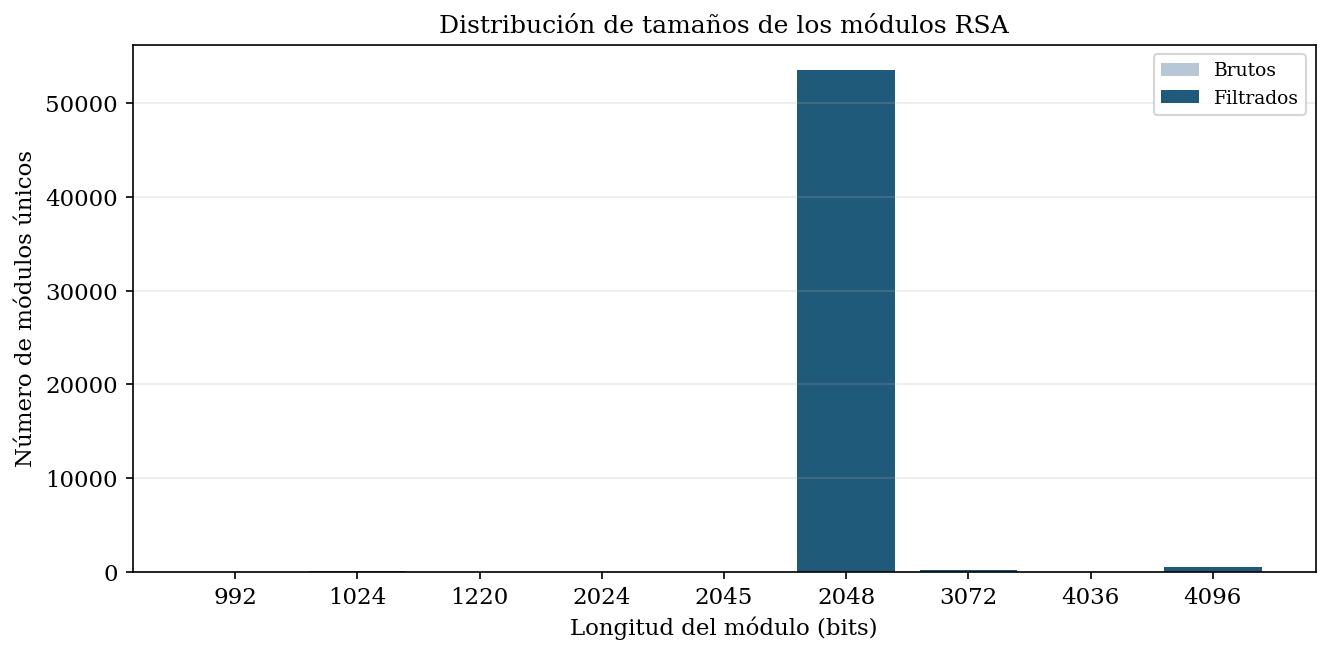

Figura guardada en: /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/resultados/ctlogs/distribucion_bits_modulos.png


In [112]:
bit_lengths = pd.Series([int(value, 16).bit_length() for value in global_moduli], name="bits")
df_bitlengths = bit_lengths.value_counts().sort_index().rename_axis("Bits").reset_index(name="Módulos brutos")

valid_bit_lengths = pd.Series([int(value, 16).bit_length() for value in valid_moduli], name="bits")
df_valid_bitlengths = valid_bit_lengths.value_counts().sort_index().rename_axis("Bits").reset_index(name="Módulos RSA plausibles")

df_bitlengths = df_bitlengths.merge(df_valid_bitlengths, on="Bits", how="left").fillna(0)
df_bitlengths["Módulos RSA plausibles"] = df_bitlengths["Módulos RSA plausibles"].astype(int)
bitlengths_csv = RESULTS_CTLOGS_DIR / "distribucion_bits_modulos.csv"
df_bitlengths.to_csv(bitlengths_csv, index=False)

display(df_bitlengths)

plt.figure(figsize=(9, 4.5))
plt.bar(df_bitlengths["Bits"].astype(str), df_bitlengths["Módulos brutos"], color="#b7c7d6", label="Brutos")
plt.bar(df_bitlengths["Bits"].astype(str), df_bitlengths["Módulos RSA plausibles"], color="#1f5a7a", label="Filtrados")
plt.title("Distribución de tamaños de los módulos RSA")
plt.xlabel("Longitud del módulo (bits)")
plt.ylabel("Número de módulos únicos")
plt.grid(axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()
bitlengths_png = RESULTS_CTLOGS_DIR / "distribucion_bits_modulos.png"
plt.savefig(bitlengths_png, dpi=200)
plt.show()
print(f"Figura guardada en: {bitlengths_png}")


## Ejecución del ataque real

La ejecución usa el binario C++/GMP generado y compilado al comienzo del notebook. Si `RUN_REAL_BATCH_GCD = True`, el ataque se ejecuta desde cero sobre el conjunto filtrado de módulos RSA plausibles y sobrescribe la salida anterior.


In [113]:
batch_output_path = RESULTS_CTLOGS_DIR / "batch_gcd_real_output.txt"
batch_summary_path = RESULTS_CTLOGS_DIR / "batch_gcd_real_summary.csv"

if not RUN_REAL_BATCH_GCD:
    raise RuntimeError(
        "RUN_REAL_BATCH_GCD está desactivado. Actívalo para generar los resultados reales desde cero."
    )

cmd = [str(CPP_BIN), str(FINAL_MODULI), str(MAX_REPORTADOS)]
returncode, output, elapsed = run_command(cmd, timeout=TIMEOUT)
batch_output_path.write_text(output, encoding="utf-8")

if returncode != 0:
    print(output[-4000:])
    raise RuntimeError(f"Batch GCD terminó con código {returncode}")

print(output[-4000:])
print(f"Salida completa guardada en: {batch_output_path}")


 Binary Tree Batch GCD — Datos Reales
Archivo          : /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/resultados/ctlogs/moduli_hex_final_principal.txt
Threads          : 18 (OpenMP)
--------------------------------------------

[Setup] 54275 modulos cargados desde /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/resultados/ctlogs/moduli_hex_final_principal.txt
  Primer modulo : 2045 bits
  Ultimo modulo : 2048 bits

  Tiempo de carga  : 52.87 ms

[Fase 1] Arbol de productos + GCD en linea
  Niveles construidos  : 16
  GCDs no triviales    : 0
  CPU Time             : 23753.25 ms

[Fase 2] Agregacion en variable B
  B bit-length         : 1 bits
  CPU Time             : 0.00 ms


[Fase 3] Enumeracion final
  Claves vulnerables   : 0
  CPU Time             : 2.96 ms

 Tiempo total algoritmo: 23756.22 ms

Salida completa guardada en: /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/resultados/ctlogs/batch_gcd_real

In [114]:
def extract_number(pattern, text, cast=float):
    match = re.search(pattern, text)
    if not match:
        return None
    return cast(match.group(1))

summary = {
    "modulos_unicos_brutos": len(global_moduli),
    "modulos_rsa_plausibles": len(valid_moduli),
    "modulos_descartados_validacion": len(rejected_moduli),
    "logs_ct_archive": len(df_logs) if "df_logs" in globals() else 0,
    "logs_incompletos": int((~df_logs["Completo"]).sum()) if not df_logs.empty else 0,
    "gcds_no_triviales_fase_1": extract_number(r"GCDs no triviales\s*:\s*(\d+)", output, int),
    "claves_vulnerables": extract_number(r"Claves vulnerables\s*:\s*(\d+)", output, int),
    "tiempo_fase_1_ms": extract_number(r"\[Fase 1\][\s\S]*?CPU Time\s*:\s*([0-9.]+) ms", output),
    "tiempo_fase_2_ms": extract_number(r"\[Fase 2\][\s\S]*?CPU Time\s*:\s*([0-9.]+) ms", output),
    "tiempo_fase_3_ms": extract_number(r"\[Fase 3\][\s\S]*?CPU Time\s*:\s*([0-9.]+) ms", output),
    "tiempo_total_algoritmo_ms": extract_number(r"Tiempo total algoritmo:\s*([0-9.]+) ms", output),
    "tiempo_total_notebook_s": elapsed,
}

# Alias corto para compatibilidad visual con celdas anteriores.
summary["modulos_unicos"] = summary["modulos_rsa_plausibles"]

df_summary = pd.DataFrame([summary])
df_summary.to_csv(batch_summary_path, index=False)
display(df_summary)
print(f"Resumen guardado en: {batch_summary_path}")


,modulos_unicos_brutos,modulos_rsa_plausibles,modulos_descartados_validacion,logs_ct_archive,logs_incompletos,gcds_no_triviales_fase_1,claves_vulnerables,tiempo_fase_1_ms,tiempo_fase_2_ms,tiempo_fase_3_ms,tiempo_total_algoritmo_ms,tiempo_total_notebook_s,modulos_unicos
0,54278,54275,3,20,0,0,0,23753.25,0.0,2.96,23756.22,24.234795,54275


Resumen guardado en: /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/resultados/ctlogs/batch_gcd_real_summary.csv


,Métrica,Valor
0,Módulos RSA únicos brutos,54278.00000
1,Módulos RSA plausibles analizados,54275.00000
2,Módulos descartados en validación,3.00000
3,Logs CT con módulos extraídos,20.00000
4,Logs incompletos al ejecutar,0.00000
5,GCDs no triviales en fase 1,0.00000
6,Claves vulnerables detectadas,0.00000
7,Tiempo total del algoritmo (s),23.75622


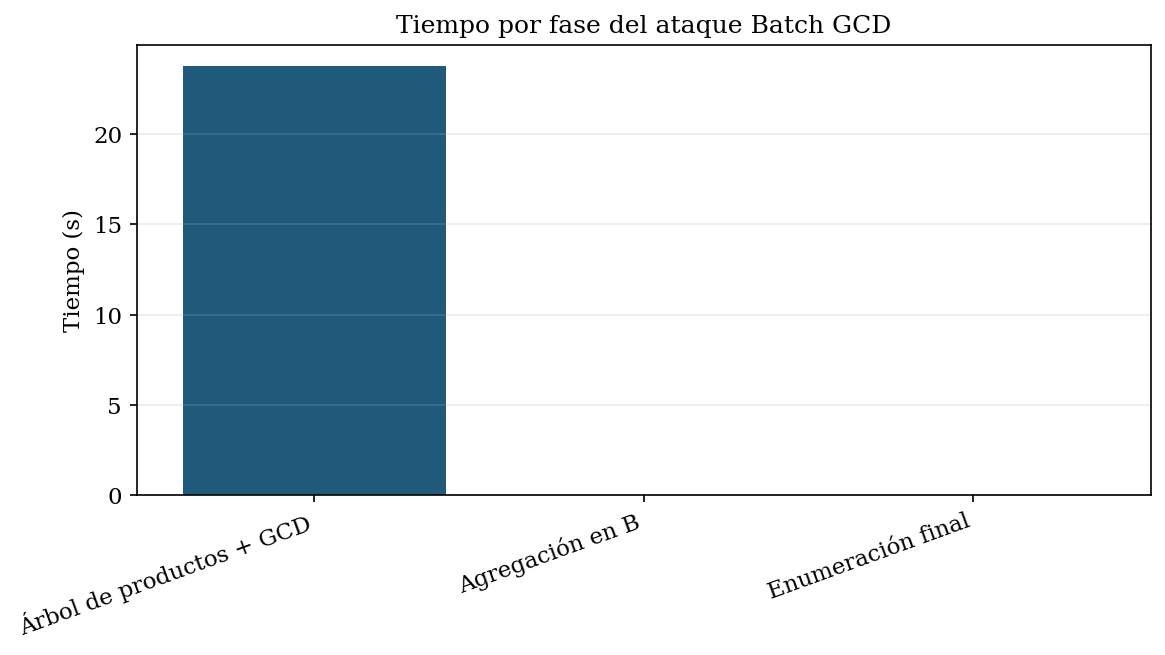

Figura guardada en: /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/resultados/ctlogs/tiempo_por_fase_batch_gcd.png
Tabla final guardada en: /Users/davidquinza/Desktop/Máster Data Science/TFM/TFM_David_Quinzaños/resultados/ctlogs/tabla_resultados_finales.csv


In [115]:
tabla_resultados = pd.DataFrame([
    ["Módulos RSA únicos brutos", summary["modulos_unicos_brutos"]],
    ["Módulos RSA plausibles analizados", summary["modulos_rsa_plausibles"]],
    ["Módulos descartados en validación", summary["modulos_descartados_validacion"]],
    ["Logs CT con módulos extraídos", int((df_logs["Módulos únicos"] > 0).sum()) if not df_logs.empty else 0],
    ["Logs incompletos al ejecutar", summary["logs_incompletos"]],
    ["GCDs no triviales en fase 1", summary["gcds_no_triviales_fase_1"]],
    ["Claves vulnerables detectadas", summary["claves_vulnerables"]],
    ["Tiempo total del algoritmo (s)", None if summary["tiempo_total_algoritmo_ms"] is None else summary["tiempo_total_algoritmo_ms"] / 1000],
], columns=["Métrica", "Valor"])

tabla_csv = RESULTS_CTLOGS_DIR / "tabla_resultados_finales.csv"
tabla_resultados.to_csv(tabla_csv, index=False)
display(tabla_resultados)

phase_times = pd.DataFrame([
    ["Árbol de productos + GCD", summary["tiempo_fase_1_ms"]],
    ["Agregación en B", summary["tiempo_fase_2_ms"]],
    ["Enumeración final", summary["tiempo_fase_3_ms"]],
], columns=["Fase", "Tiempo (ms)"]).dropna()

if not phase_times.empty:
    plt.figure(figsize=(8, 4.5))
    plt.bar(phase_times["Fase"], phase_times["Tiempo (ms)"] / 1000, color=["#1f5a7a", "#d2872c", "#47733f"])
    plt.ylabel("Tiempo (s)")
    plt.title("Tiempo por fase del ataque Batch GCD")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    phases_png = RESULTS_CTLOGS_DIR / "tiempo_por_fase_batch_gcd.png"
    plt.savefig(phases_png, dpi=200)
    plt.show()
    print(f"Figura guardada en: {phases_png}")

print(f"Tabla final guardada en: {tabla_csv}")


# Conclusión del flujo experimental

Este notebook deja conectadas las tres piezas principales del trabajo experimental:

- la implementación C++/GMP del algoritmo usado;
- la comparación sintética que justifica su uso frente a las alternativas Python;
- el ataque sobre módulos reales extraídos de CT Logs.

Al actualizar `Datos/modulos.txt`, basta con volver a ejecutar desde la sección de consolidación para regenerar el conjunto final, repetir el ataque y actualizar las tablas.
